# Fair Price via Feasible Dynamic Hedging

This notebook estimates a bilateral fair price for a generally path-dependent contract using feasible discrete-time dynamic hedging. The portfolio contains only the underlying asset and the bank account.

The stock position is a bounded finite sigmoidal expansion

$$a_k = a_{\max}\tanh\left(c_0+\sum_{j=1}^{m} c_j\sigma(w_j^\top X_k+b_j)\right),$$

where the user chooses `m = N_SIGMOIDAL_FUNCTIONS`. The default is `m = 2` for fast runs.


In [ ]:
# Install Yahoo Finance downloader in Colab.
!pip -q install yfinance


In [ ]:
# Fair Price via Feasible Dynamic Hedging
# Portfolio instruments: underlying asset + bank account only.
# Daily rebalancing. Path-dependent payoff allowed.
# The stock position is a bounded finite sigmoidal expansion with user-selected size m.



## Imports


In [ ]:
import math
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import torch
from torch import nn
import torch.nn.functional as F

# Reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)



Using device: cpu


## User inputs


In [ ]:
# Set USE_INTERACTIVE_INPUTS = False if you prefer to hard-code the inputs.
USE_INTERACTIVE_INPUTS = True
DEFAULT_N_SIGMOIDAL_FUNCTIONS = 2

if USE_INTERACTIVE_INPUTS:
    TICKER = input("Ticker, e.g. AAPL, MSFT, SPY: ").strip().upper() or "AAPL"
    T_DAYS = int(input("Maturity T in trading days, e.g. 63: ").strip() or "63")
    N_SIGMOIDAL_FUNCTIONS = int(
        input("Number of sigmoidal functions m, e.g. 2 for fast runs: ").strip()
        or str(DEFAULT_N_SIGMOIDAL_FUNCTIONS)
    )
else:
    TICKER = "AAPL"
    T_DAYS = 63
    N_SIGMOIDAL_FUNCTIONS = DEFAULT_N_SIGMOIDAL_FUNCTIONS

# Keep at least one basis function.
N_SIGMOIDAL_FUNCTIONS = max(1, int(N_SIGMOIDAL_FUNCTIONS))

# Historical lookback used to generate scenarios.
HISTORY_YEARS = 10

# Number of historical-return scenarios. Increase this for more stable results.
N_SCENARIOS = 1500

# Train/validation split. Validation CVaR is used for the reported fair-price comparison.
TRAIN_FRACTION = 0.80

# Annual continuously compounded risk-free rate.
R_ANNUAL = 0.03

# CVaR confidence level.
ALPHA = 0.95

# Contract settings. The payoff is for one contract unit, not a 100-share option lot.
# Supported: "european_call", "european_put", "asian_call", "asian_put",
#            "lookback_call", "lookback_put", "up_and_out_call", "down_and_out_put".
CONTRACT_TYPE = "lookback_call"
CONTRACT_MULTIPLIER = 1.0

# If STRIKE is None, it will be set to the latest downloaded spot price S0.
STRIKE = None

# If BARRIER is None, it will be set automatically for barrier examples.
BARRIER = None

# Position bound in shares per contract unit.
# For one vanilla call, values around 1-2 are natural. Increase for more aggressive hedging.
A_MAX_MULTIPLIER = 2.0

# Optimization settings.
# The stock position is represented by m finite sigmoidal basis functions.
# Start with m=2 for speed; increase to 4, 8, 16, ... for richer hedges.
SIGMOIDAL_ACTIVATION = "tanh"  # Supported: "tanh" or "logistic".
EPOCHS = 350
LEARNING_RATE = 2e-3
POSITION_PENALTY = 1e-5
N_RESTARTS = 1

# Fair-price grid settings. Increase N_PRICE_GRID for smoother but slower pricing.
N_PRICE_GRID = 9

print({
    "ticker": TICKER,
    "T_days": T_DAYS,
    "contract": CONTRACT_TYPE,
    "history_years": HISTORY_YEARS,
    "n_scenarios": N_SCENARIOS,
    "alpha": ALPHA,
    "n_sigmoidal_functions": N_SIGMOIDAL_FUNCTIONS,
})



Ticker, e.g. AAPL, MSFT, SPY: AAPL
Maturity T in trading days, e.g. 63: 60
Number of sigmoidal functions m, e.g. 2 for fast runs: 2
{'ticker': 'AAPL', 'T_days': 60, 'contract': 'lookback_call', 'history_years': 10, 'n_scenarios': 1500, 'alpha': 0.95, 'n_sigmoidal_functions': 2}


## Data download and scenario generation


Latest adjusted close S0 for AAPL: 300.2300
Strike K: 300.2300
Scenario paths shape: (1500, 61)
Position bound a_max: 2.0000 shares per contract unit


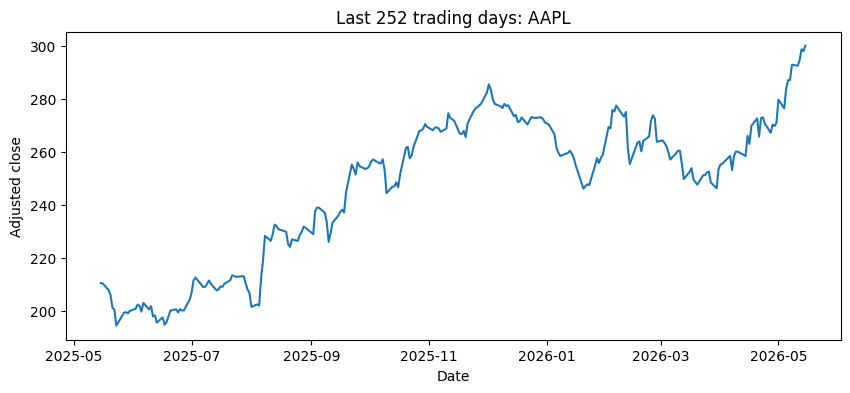

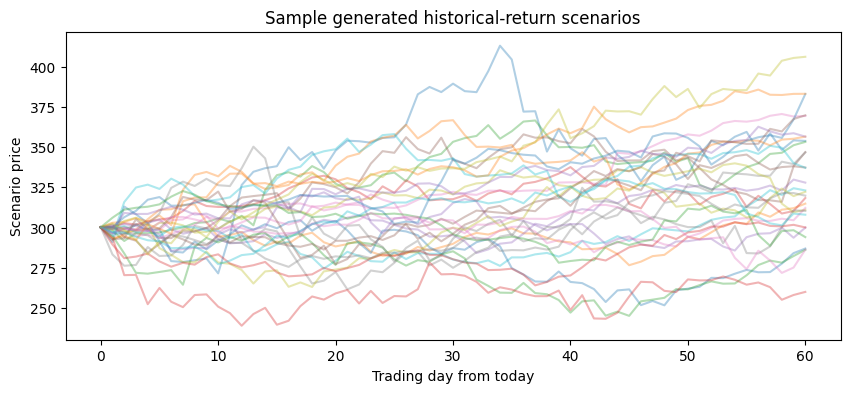

In [ ]:
def extract_close_column(raw: pd.DataFrame) -> pd.Series:
    """Extract a single Close column from yfinance output, robustly handling MultiIndex columns."""
    if raw.empty:
        raise ValueError("Downloaded data is empty. Check the ticker or Yahoo Finance availability.")

    if isinstance(raw.columns, pd.MultiIndex):
        # yfinance may return MultiIndex columns even for one ticker.
        for level in range(raw.columns.nlevels):
            labels = list(raw.columns.get_level_values(level))
            if "Close" in labels:
                close = raw.xs("Close", axis=1, level=level)
                if isinstance(close, pd.DataFrame):
                    close = close.iloc[:, 0]
                return close.dropna().astype(float)
        raise ValueError("Could not find a Close column in the downloaded MultiIndex data.")

    if "Close" not in raw.columns:
        raise ValueError("Could not find a Close column in the downloaded data.")
    return raw["Close"].dropna().astype(float)


def download_adjusted_close(ticker: str, history_years: int = 10) -> pd.Series:
    """Download adjusted daily close prices from Yahoo Finance through yfinance."""
    period = f"{history_years}y"
    raw = yf.download(
        tickers=ticker,
        period=period,
        interval="1d",
        auto_adjust=True,
        progress=False,
        threads=True,
    )
    close = extract_close_column(raw)
    if len(close) < 260:
        warnings.warn("The downloaded history is short; scenario generation may be unstable.")
    return close


def make_historical_scenarios(
    close: pd.Series,
    horizon_days: int,
    n_scenarios: int,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create future price paths by sampling historical daily log-return blocks.

    Returns
    -------
    paths : array, shape (n_scenarios, horizon_days + 1)
        Price paths starting at the latest observed spot S0.
    sampled_returns : array, shape (n_scenarios, horizon_days)
        The sampled log-return blocks used to build the paths.
    """
    if horizon_days < 1:
        raise ValueError("horizon_days must be positive.")

    rng = np.random.default_rng(seed)
    s0 = float(close.iloc[-1])
    log_returns = np.log(close / close.shift(1)).dropna().to_numpy(dtype=float)

    if len(log_returns) >= horizon_days:
        # Rolling blocks preserve local serial dependence inside each block.
        windows = np.lib.stride_tricks.sliding_window_view(log_returns, window_shape=horizon_days)
        replace = len(windows) < n_scenarios
        idx = rng.choice(len(windows), size=n_scenarios, replace=replace)
        sampled_returns = windows[idx]
    else:
        # Fallback for very long maturities relative to history.
        warnings.warn(
            "T_DAYS exceeds available return history; using iid bootstrap of daily returns instead of rolling blocks."
        )
        sampled_returns = rng.choice(log_returns, size=(n_scenarios, horizon_days), replace=True)

    future_prices = s0 * np.exp(np.cumsum(sampled_returns, axis=1))
    paths = np.concatenate([np.full((n_scenarios, 1), s0), future_prices], axis=1)
    return paths.astype(np.float32), sampled_returns.astype(np.float32)


close = download_adjusted_close(TICKER, HISTORY_YEARS)
S0 = float(close.iloc[-1])

if STRIKE is None:
    STRIKE = S0
if BARRIER is None:
    # Default barriers are only used by barrier payoff examples.
    if CONTRACT_TYPE == "up_and_out_call":
        BARRIER = 1.25 * S0
    elif CONTRACT_TYPE == "down_and_out_put":
        BARRIER = 0.75 * S0
    else:
        BARRIER = np.nan

A_MAX = A_MAX_MULTIPLIER * CONTRACT_MULTIPLIER

paths, sampled_returns = make_historical_scenarios(
    close=close,
    horizon_days=T_DAYS,
    n_scenarios=N_SCENARIOS,
    seed=SEED,
)

print(f"Latest adjusted close S0 for {TICKER}: {S0:.4f}")
print(f"Strike K: {STRIKE:.4f}")
print(f"Scenario paths shape: {paths.shape}")
print(f"Position bound a_max: {A_MAX:.4f} shares per contract unit")

plt.figure(figsize=(10, 4))
plt.plot(close.tail(252))
plt.title(f"Last 252 trading days: {TICKER}")
plt.xlabel("Date")
plt.ylabel("Adjusted close")
plt.show()

plt.figure(figsize=(10, 4))
for i in range(min(30, len(paths))):
    plt.plot(paths[i], alpha=0.35)
plt.title("Sample generated historical-return scenarios")
plt.xlabel("Trading day from today")
plt.ylabel("Scenario price")
plt.show()



## Path-dependent payoff


ContractConfig(contract_type='lookback_call', strike=300.2300109863281, barrier=None, multiplier=1.0)
count    1500.000000
mean       41.839317
std        31.348135
min         0.000000
50%        36.402252
90%        79.658301
95%        97.819629
99%       148.126714
max       183.876099
dtype: float64


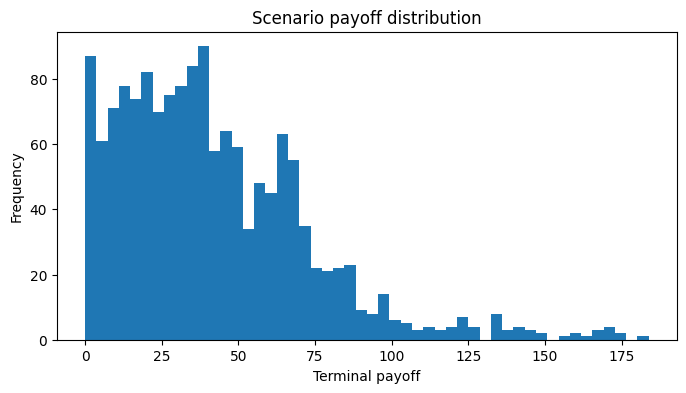

In [ ]:
@dataclass
class ContractConfig:
    contract_type: str
    strike: float
    barrier: Optional[float] = None
    multiplier: float = 1.0


def compute_contract_payoff(paths: np.ndarray, contract: ContractConfig) -> np.ndarray:
    """
    Compute the path-dependent terminal payoff for each scenario.

    To implement a custom path-dependent claim, add a new branch below.
    The returned payoff is in terminal currency units, before discounting.
    """
    ctype = contract.contract_type.lower()
    K = float(contract.strike)
    multiplier = float(contract.multiplier)

    S_full = paths
    S_future = paths[:, 1:]
    S_T = paths[:, -1]

    if ctype == "european_call":
        payoff = np.maximum(S_T - K, 0.0)

    elif ctype == "european_put":
        payoff = np.maximum(K - S_T, 0.0)

    elif ctype == "asian_call":
        avg_price = S_future.mean(axis=1)
        payoff = np.maximum(avg_price - K, 0.0)

    elif ctype == "asian_put":
        avg_price = S_future.mean(axis=1)
        payoff = np.maximum(K - avg_price, 0.0)

    elif ctype == "lookback_call":
        running_max = S_full.max(axis=1)
        payoff = np.maximum(running_max - K, 0.0)

    elif ctype == "lookback_put":
        running_min = S_full.min(axis=1)
        payoff = np.maximum(K - running_min, 0.0)

    elif ctype == "up_and_out_call":
        if contract.barrier is None or not np.isfinite(contract.barrier):
            raise ValueError("up_and_out_call requires a finite upper barrier.")
        knocked_out = S_full.max(axis=1) >= float(contract.barrier)
        payoff = np.where(knocked_out, 0.0, np.maximum(S_T - K, 0.0))

    elif ctype == "down_and_out_put":
        if contract.barrier is None or not np.isfinite(contract.barrier):
            raise ValueError("down_and_out_put requires a finite lower barrier.")
        knocked_out = S_full.min(axis=1) <= float(contract.barrier)
        payoff = np.where(knocked_out, 0.0, np.maximum(K - S_T, 0.0))

    else:
        raise ValueError(f"Unsupported contract_type: {contract.contract_type}")

    return (multiplier * payoff).astype(np.float32)


contract = ContractConfig(
    contract_type=CONTRACT_TYPE,
    strike=float(STRIKE),
    barrier=None if not np.isfinite(BARRIER) else float(BARRIER),
    multiplier=float(CONTRACT_MULTIPLIER),
)

payoff = compute_contract_payoff(paths, contract)

print(contract)
print(pd.Series(payoff).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure(figsize=(8, 4))
plt.hist(payoff, bins=50)
plt.title("Scenario payoff distribution")
plt.xlabel("Terminal payoff")
plt.ylabel("Frequency")
plt.show()



## Discounted market and self-financing portfolio


In [ ]:
def discount_market(
    paths: np.ndarray,
    payoff: np.ndarray,
    r_annual: float,
    trading_days_per_year: int = 252,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Convert stock paths and payoff to discounted units."""
    n_steps = paths.shape[1] - 1
    t = np.arange(n_steps + 1, dtype=np.float32) / float(trading_days_per_year)
    bank = np.exp(float(r_annual) * t).astype(np.float32)
    discounted_paths = paths / bank[None, :]
    discounted_payoff = payoff / bank[-1]
    return discounted_paths.astype(np.float32), discounted_payoff.astype(np.float32), bank


S_disc, payoff_disc, bank_account = discount_market(paths, payoff, R_ANNUAL)
print("Terminal bank-account growth B_T:", float(bank_account[-1]))
print("Mean discounted payoff:", float(payoff_disc.mean()))



Terminal bank-account growth B_T: 1.0071684122085571
Mean discounted payoff: 41.541526794433594


## State features for the finite sigmoidal feedback hedge


In [ ]:
def build_state_features(paths: np.ndarray, strike: float) -> np.ndarray:
    """
    Build non-anticipative state features for each scenario and rebalancing date.

    Output shape is (n_scenarios, n_steps, n_features).
    Features at time k use only path values up to and including S_k.
    """
    paths = np.asarray(paths, dtype=np.float32)
    M, N_plus_1 = paths.shape
    N = N_plus_1 - 1
    S0 = paths[:, [0]]
    spot = paths[:, :-1]

    running_max = np.maximum.accumulate(paths, axis=1)[:, :-1]
    running_min = np.minimum.accumulate(paths, axis=1)[:, :-1]
    running_sum = np.cumsum(paths, axis=1)[:, :-1]
    counts = np.arange(1, N + 1, dtype=np.float32)[None, :]
    running_avg = running_sum / counts

    full_log = np.log(paths)
    observed_log_returns = np.diff(full_log, axis=1)

    last_return = np.zeros((M, N), dtype=np.float32)
    if N > 1:
        # At time k, the latest observed return is S_k/S_{k-1}; do not use S_{k+1}.
        last_return[:, 1:] = observed_log_returns[:, :-1]

    realized_vol = np.zeros((M, N), dtype=np.float32)
    lookback = 21
    for k in range(1, N):
        start = max(0, k - lookback)
        window = observed_log_returns[:, start:k]
        realized_vol[:, k] = window.std(axis=1) * math.sqrt(252.0)

    time_left = ((N - np.arange(N, dtype=np.float32)) / float(N))[None, :]
    time_left = np.repeat(time_left, repeats=M, axis=0)

    log_spot_rel = np.log(spot / S0)
    log_moneyness = np.log(spot / float(strike))
    run_max_rel = running_max / S0 - 1.0
    run_min_rel = running_min / S0 - 1.0
    run_avg_rel = running_avg / S0 - 1.0
    drawdown = spot / np.maximum(running_max, 1e-12) - 1.0

    features = np.stack(
        [
            log_spot_rel,
            log_moneyness,
            run_max_rel,
            run_min_rel,
            run_avg_rel,
            drawdown,
            last_return,
            realized_vol,
            time_left,
        ],
        axis=-1,
    )
    return features.astype(np.float32)


class StandardScaler3D:
    """Simple scaler for arrays shaped (n_scenarios, n_steps, n_features)."""

    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X: np.ndarray):
        flat = X.reshape(-1, X.shape[-1])
        self.mean_ = flat.mean(axis=0, keepdims=True).astype(np.float32)
        self.std_ = flat.std(axis=0, keepdims=True).astype(np.float32)
        self.std_ = np.where(self.std_ < 1e-8, 1.0, self.std_)
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.mean_ is None or self.std_ is None:
            raise RuntimeError("Scaler has not been fitted.")
        return ((X - self.mean_[None, :, :]) / self.std_[None, :, :]).astype(np.float32)


def split_train_validation(n: int, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """Create train and validation indices."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_train = int(round(train_fraction * n))
    n_train = min(max(n_train, 1), n - 1)
    return idx[:n_train], idx[n_train:]


features_raw = build_state_features(paths, STRIKE)
train_idx, val_idx = split_train_validation(len(paths), TRAIN_FRACTION, SEED)

scaler = StandardScaler3D().fit(features_raw[train_idx])
features = scaler.transform(features_raw)

train_data = {
    "features": features[train_idx],
    "S_disc": S_disc[train_idx],
    "payoff_disc": payoff_disc[train_idx],
}
val_data = {
    "features": features[val_idx],
    "S_disc": S_disc[val_idx],
    "payoff_disc": payoff_disc[val_idx],
}

print("Raw feature shape:", features_raw.shape)
print("Train scenarios:", len(train_idx), "Validation scenarios:", len(val_idx))



Raw feature shape: (1500, 60, 9)
Train scenarios: 1200 Validation scenarios: 300


## Dynamic hedging model and CVaR optimization


In [ ]:
@dataclass
class OptimConfig:
    alpha: float = 0.95
    epochs: int = 350
    lr: float = 2e-3
    n_sigmoidal_functions: int = 2
    sigmoid_activation: str = "tanh"
    position_penalty: float = 1e-5
    n_restarts: int = 1
    seed: int = 42


class SigmoidalDeltaNet(nn.Module):
    """
    Bounded finite sigmoidal expansion for the stock position.

    a_k = a_max * tanh(c0 + sum_j c_j * sigma(w_j^T X_k + b_j))

    The same parameters are shared across dates, while time-to-maturity is included
    in X_k. This keeps the model small and fast while preserving time dependence.
    """

    def __init__(
        self,
        input_dim: int,
        a_max: float,
        n_sigmoidal_functions: int = 2,
        sigmoid_activation: str = "tanh",
    ):
        super().__init__()
        if n_sigmoidal_functions < 1:
            raise ValueError("n_sigmoidal_functions must be at least 1.")
        if sigmoid_activation not in {"tanh", "logistic"}:
            raise ValueError("sigmoid_activation must be 'tanh' or 'logistic'.")

        self.input_to_basis = nn.Linear(input_dim, n_sigmoidal_functions)
        self.basis_to_output = nn.Linear(n_sigmoidal_functions, 1, bias=True)
        self.a_max = float(a_max)
        self.sigmoid_activation = sigmoid_activation

    def _basis_activation(self, z: torch.Tensor) -> torch.Tensor:
        # Both tanh and logistic are sigmoidal functions.
        if self.sigmoid_activation == "logistic":
            return torch.sigmoid(z)
        return torch.tanh(z)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # X has shape (batch, n_steps, input_dim).
        basis_values = self._basis_activation(self.input_to_basis(X))
        raw = self.basis_to_output(basis_values).squeeze(-1)
        return self.a_max * torch.tanh(raw)


def terminal_pnl(
    model: nn.Module,
    X: torch.Tensor,
    S_disc_t: torch.Tensor,
    payoff_disc_t: torch.Tensor,
    x: float,
    epsilon: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Compute discounted terminal P&L for a self-financing stock+bank strategy.

    pnl = x + sum_k a_k * (S_{k+1} - S_k) + epsilon * payoff
    epsilon = -1 for writer, +1 for buyer.
    """
    a = model(X)
    dS = S_disc_t[:, 1:] - S_disc_t[:, :-1]
    trading_gains = torch.sum(a * dS, dim=1)
    pnl = float(x) + trading_gains + int(epsilon) * payoff_disc_t
    return pnl, a


def cvar_rockafellar_uryasev(losses: torch.Tensor, eta: torch.Tensor, alpha: float) -> torch.Tensor:
    """Differentiable empirical CVaR objective for a trainable eta."""
    return eta + torch.mean(F.relu(losses - eta)) / (1.0 - float(alpha))


def empirical_cvar_np(losses: np.ndarray, alpha: float) -> float:
    """Empirical CVaR using the Rockafellar-Uryasev representation at the empirical quantile."""
    losses = np.asarray(losses, dtype=float)
    q = float(np.quantile(losses, alpha))
    return float(q + np.mean(np.maximum(losses - q, 0.0)) / (1.0 - alpha))


def to_torch_data(data: Dict[str, np.ndarray]) -> Dict[str, torch.Tensor]:
    """Move scenario arrays to the selected PyTorch device."""
    return {
        "features": torch.as_tensor(data["features"], dtype=torch.float32, device=DEVICE),
        "S_disc": torch.as_tensor(data["S_disc"], dtype=torch.float32, device=DEVICE),
        "payoff_disc": torch.as_tensor(data["payoff_disc"], dtype=torch.float32, device=DEVICE),
    }


def evaluate_strategy(
    model: nn.Module,
    data: Dict[str, np.ndarray],
    x: float,
    epsilon: int,
    alpha: float,
) -> Dict[str, float]:
    """Evaluate mean P&L, downside loss, VaR, CVaR, and average absolute position."""
    model.eval()
    tdata = to_torch_data(data)
    with torch.no_grad():
        pnl, a = terminal_pnl(model, tdata["features"], tdata["S_disc"], tdata["payoff_disc"], x, epsilon)
    pnl_np = pnl.detach().cpu().numpy()
    a_np = a.detach().cpu().numpy()
    losses = np.maximum(-pnl_np, 0.0)
    return {
        "mean_pnl": float(np.mean(pnl_np)),
        "std_pnl": float(np.std(pnl_np)),
        "mean_loss": float(np.mean(losses)),
        "var_loss": float(np.quantile(losses, alpha)),
        "cvar_loss": empirical_cvar_np(losses, alpha),
        "prob_loss": float(np.mean(pnl_np < 0.0)),
        "avg_abs_position": float(np.mean(np.abs(a_np))),
    }


def train_one_strategy(
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
    x: float,
    epsilon: int,
    a_max: float,
    config: OptimConfig,
    restart_seed: int,
) -> Dict[str, Any]:
    """Train one dynamic hedging strategy for a fixed premium side."""
    torch.manual_seed(restart_seed)
    np.random.seed(restart_seed)
    random.seed(restart_seed)

    input_dim = train_data["features"].shape[-1]
    model = SigmoidalDeltaNet(
        input_dim=input_dim,
        a_max=a_max,
        n_sigmoidal_functions=config.n_sigmoidal_functions,
        sigmoid_activation=config.sigmoid_activation,
    ).to(DEVICE)

    # Initial eta is set from the no-hedge downside loss, which stabilizes CVaR training.
    nohedge_pnl = float(x) + int(epsilon) * train_data["payoff_disc"]
    nohedge_losses = np.maximum(-nohedge_pnl, 0.0)
    eta0 = float(np.quantile(nohedge_losses, config.alpha))
    eta = nn.Parameter(torch.tensor(eta0, dtype=torch.float32, device=DEVICE))

    optimizer = torch.optim.Adam(list(model.parameters()) + [eta], lr=config.lr)
    ttrain = to_torch_data(train_data)

    history = []
    for epoch in range(config.epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        pnl, a = terminal_pnl(
            model=model,
            X=ttrain["features"],
            S_disc_t=ttrain["S_disc"],
            payoff_disc_t=ttrain["payoff_disc"],
            x=x,
            epsilon=epsilon,
        )
        losses = F.relu(-pnl)
        cvar_obj = cvar_rockafellar_uryasev(losses, eta, config.alpha)

        # A small regularizer discourages unnecessarily violent stock positions.
        objective = cvar_obj + config.position_penalty * torch.mean(a * a)
        objective.backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + [eta], max_norm=10.0)
        optimizer.step()

        if epoch % max(1, config.epochs // 10) == 0 or epoch == config.epochs - 1:
            history.append(float(cvar_obj.detach().cpu()))

    train_stats = evaluate_strategy(model, train_data, x, epsilon, config.alpha)
    val_stats = evaluate_strategy(model, val_data, x, epsilon, config.alpha)

    return {
        "model": model,
        "eta": float(eta.detach().cpu()),
        "train": train_stats,
        "validation": val_stats,
        "history": history,
        "x": float(x),
        "epsilon": int(epsilon),
    }


def train_best_strategy(
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
    x: float,
    epsilon: int,
    a_max: float,
    config: OptimConfig,
) -> Dict[str, Any]:
    """Train several restarts and keep the model with lowest validation CVaR."""
    best = None
    for r in range(config.n_restarts):
        bundle = train_one_strategy(
            train_data=train_data,
            val_data=val_data,
            x=x,
            epsilon=epsilon,
            a_max=a_max,
            config=config,
            restart_seed=config.seed + 1000 * r + 17 * int(epsilon + 2),
        )
        if best is None or bundle["validation"]["cvar_loss"] < best["validation"]["cvar_loss"]:
            best = bundle
    return best


optim_config = OptimConfig(
    alpha=ALPHA,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    n_sigmoidal_functions=N_SIGMOIDAL_FUNCTIONS,
    sigmoid_activation=SIGMOIDAL_ACTIVATION,
    position_penalty=POSITION_PENALTY,
    n_restarts=N_RESTARTS,
    seed=SEED,
)

print(optim_config)



OptimConfig(alpha=0.95, epochs=350, lr=0.002, n_sigmoidal_functions=2, sigmoid_activation='tanh', position_penalty=1e-05, n_restarts=1, seed=42)


## Fair-price search


Candidate premium grid:
[  0.          22.98006873  45.96013746  68.94020619  91.92027493
 114.90034366 137.88041239 160.86048112 183.84054985]
[1/9] Premium Y = 0.000000
    Rw=75.494012, Rb=0.000000, Rw-Rb=75.494012
[2/9] Premium Y = 22.980069
    Rw=52.513942, Rb=12.644150, Rw-Rb=39.869792
[3/9] Premium Y = 45.960137
    Rw=29.533875, Rb=35.624218, Rw-Rb=-6.090343
[4/9] Premium Y = 68.940206
    Rw=6.553803, Rb=58.604291, Rw-Rb=-52.050488
[5/9] Premium Y = 91.920275
    Rw=0.000000, Rb=81.584354, Rw-Rb=-81.584354
[6/9] Premium Y = 114.900344
    Rw=0.000000, Rb=104.564426, Rw-Rb=-104.564426
[7/9] Premium Y = 137.880412
    Rw=0.000000, Rb=127.544498, Rw-Rb=-127.544498
[8/9] Premium Y = 160.860481
    Rw=0.000000, Rb=150.524555, Rw-Rb=-150.524555
[9/9] Premium Y = 183.840550
    Rw=0.000000, Rb=173.504627, Rw-Rb=-173.504627

Fair-price estimate:
{'fair_price': 42.91496569834561, 'method': 'linear_interpolation', 'abs_diff': 0.0}
            Y  Rw_val_CVaR  Rb_val_CVaR  diff_Rw_minus_

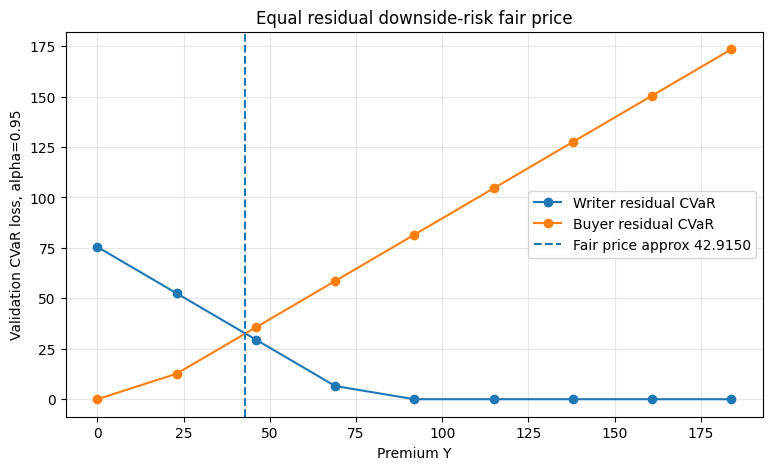

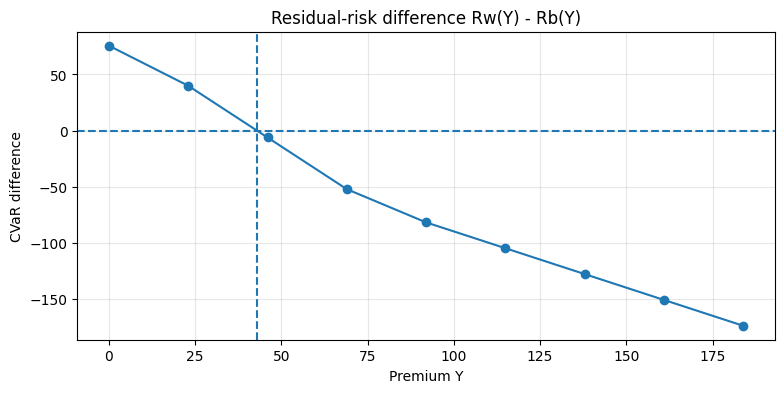

In [ ]:
def make_default_price_grid(payoff_disc: np.ndarray, n_grid: int = 9) -> np.ndarray:
    """Create a reasonable initial premium grid from the scenario payoff scale."""
    payoff_disc = np.asarray(payoff_disc, dtype=float)
    mean_payoff = float(np.mean(payoff_disc))
    max_payoff = float(np.max(payoff_disc))
    p99 = float(np.quantile(payoff_disc, 0.99))

    upper = max(1.0, 3.0 * mean_payoff, 1.25 * p99, 0.75 * max_payoff)
    if upper <= 0.0 or not np.isfinite(upper):
        upper = 1.0
    return np.linspace(0.0, upper, n_grid, dtype=float)


def run_fair_price_grid(
    price_grid: np.ndarray,
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
    a_max: float,
    config: OptimConfig,
) -> Tuple[pd.DataFrame, Dict[Tuple[float, str], Dict[str, Any]]]:
    """Train writer and buyer strategies on a premium grid."""
    rows = []
    models = {}

    for j, Y in enumerate(price_grid):
        Y = float(Y)
        print(f"[{j + 1}/{len(price_grid)}] Premium Y = {Y:.6f}")

        # Writer receives premium, pays the claim.
        writer = train_best_strategy(
            train_data=train_data,
            val_data=val_data,
            x=Y,
            epsilon=-1,
            a_max=a_max,
            config=config,
        )

        # Buyer pays premium, receives the claim.
        buyer = train_best_strategy(
            train_data=train_data,
            val_data=val_data,
            x=-Y,
            epsilon=+1,
            a_max=a_max,
            config=config,
        )

        Rw = writer["validation"]["cvar_loss"]
        Rb = buyer["validation"]["cvar_loss"]
        diff = Rw - Rb

        rows.append({
            "Y": Y,
            "Rw_val_CVaR": Rw,
            "Rb_val_CVaR": Rb,
            "diff_Rw_minus_Rb": diff,
            "writer_mean_pnl": writer["validation"]["mean_pnl"],
            "buyer_mean_pnl": buyer["validation"]["mean_pnl"],
            "writer_prob_loss": writer["validation"]["prob_loss"],
            "buyer_prob_loss": buyer["validation"]["prob_loss"],
            "writer_avg_abs_a": writer["validation"]["avg_abs_position"],
            "buyer_avg_abs_a": buyer["validation"]["avg_abs_position"],
        })

        models[(Y, "writer")] = writer
        models[(Y, "buyer")] = buyer

        print(f"    Rw={Rw:.6f}, Rb={Rb:.6f}, Rw-Rb={diff:.6f}")

    result = pd.DataFrame(rows).sort_values("Y").reset_index(drop=True)
    return result, models


def estimate_fair_price_from_grid(result: pd.DataFrame) -> Dict[str, float]:
    """Estimate fair price by finding a sign crossing of Rw-Rb or closest grid point."""
    y = result["Y"].to_numpy(dtype=float)
    d = result["diff_Rw_minus_Rb"].to_numpy(dtype=float)

    for i in range(len(y) - 1):
        if d[i] == 0.0:
            return {"fair_price": float(y[i]), "method": "exact_grid", "abs_diff": 0.0}
        if d[i] * d[i + 1] < 0.0:
            # Linear interpolation between adjacent grid points.
            y0, y1 = y[i], y[i + 1]
            d0, d1 = d[i], d[i + 1]
            fair = y0 - d0 * (y1 - y0) / (d1 - d0)
            return {"fair_price": float(fair), "method": "linear_interpolation", "abs_diff": 0.0}

    # No crossing: return the grid point with smallest absolute residual-risk gap.
    idx = int(np.argmin(np.abs(d)))
    return {"fair_price": float(y[idx]), "method": "closest_grid", "abs_diff": float(abs(d[idx]))}


price_grid = make_default_price_grid(payoff_disc, N_PRICE_GRID)
print("Candidate premium grid:")
print(price_grid)

# Run the pricing grid. This is the slowest part because it trains two dynamic hedges per premium.
result_grid, trained_models = run_fair_price_grid(
    price_grid=price_grid,
    train_data=train_data,
    val_data=val_data,
    a_max=A_MAX,
    config=optim_config,
)

fair_estimate = estimate_fair_price_from_grid(result_grid)
print()
print("Fair-price estimate:")
print(fair_estimate)
print(result_grid)

plt.figure(figsize=(9, 5))
plt.plot(result_grid["Y"], result_grid["Rw_val_CVaR"], marker="o", label="Writer residual CVaR")
plt.plot(result_grid["Y"], result_grid["Rb_val_CVaR"], marker="o", label="Buyer residual CVaR")
plt.axvline(fair_estimate["fair_price"], linestyle="--", label=f"Fair price approx {fair_estimate['fair_price']:.4f}")
plt.title("Equal residual downside-risk fair price")
plt.xlabel("Premium Y")
plt.ylabel(f"Validation CVaR loss, alpha={ALPHA}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(result_grid["Y"], result_grid["diff_Rw_minus_Rb"], marker="o")
plt.axhline(0.0, linestyle="--")
plt.axvline(fair_estimate["fair_price"], linestyle="--")
plt.title("Residual-risk difference Rw(Y) - Rb(Y)")
plt.xlabel("Premium Y")
plt.ylabel("CVaR difference")
plt.grid(True, alpha=0.3)
plt.show()



## Optional final hedges and bank-account diagnostics


     side          Y  mean_pnl    std_pnl  mean_loss   var_loss  cvar_loss  \
0  writer  42.914966  3.555232  23.256693   6.386387  26.085257  32.579044   
1   buyer  42.914966 -4.264392  29.591309  12.943114  30.370762  32.579048   

   prob_loss  avg_abs_position  
0   0.513333          0.518880  
1   0.713333          0.226742  
Max reconstruction error: 0.00020217896


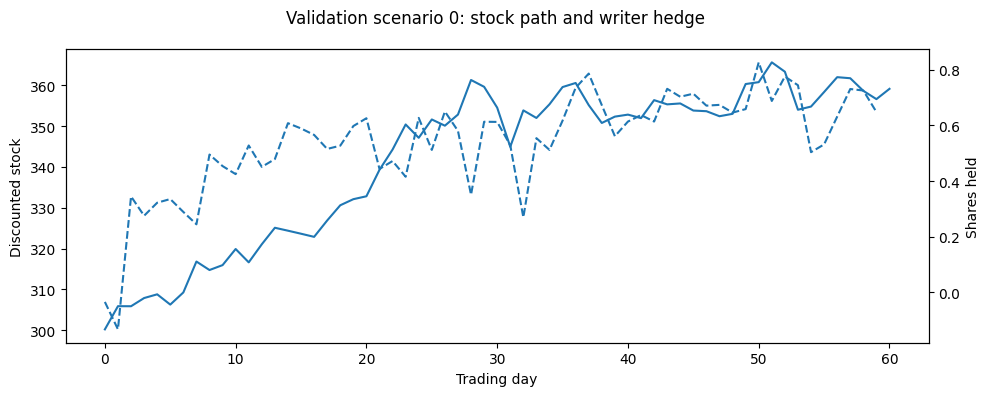

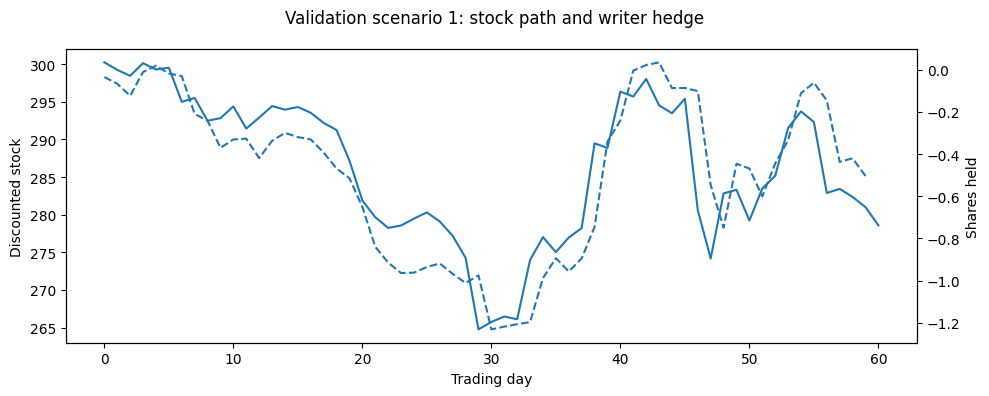

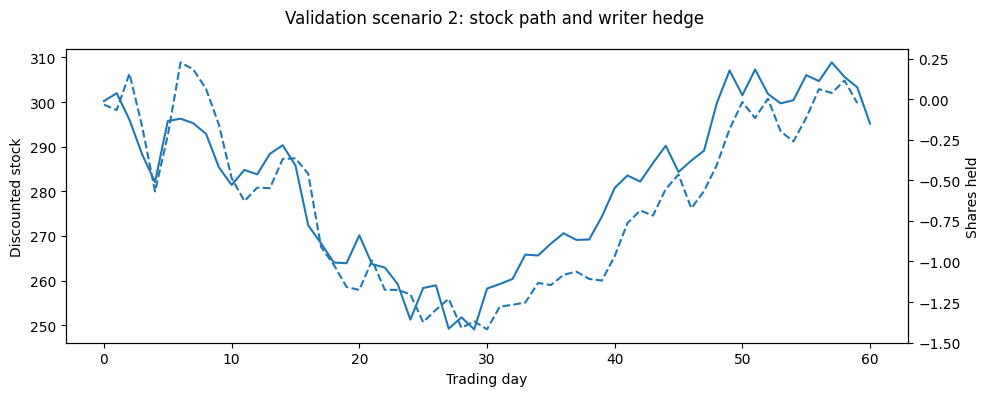

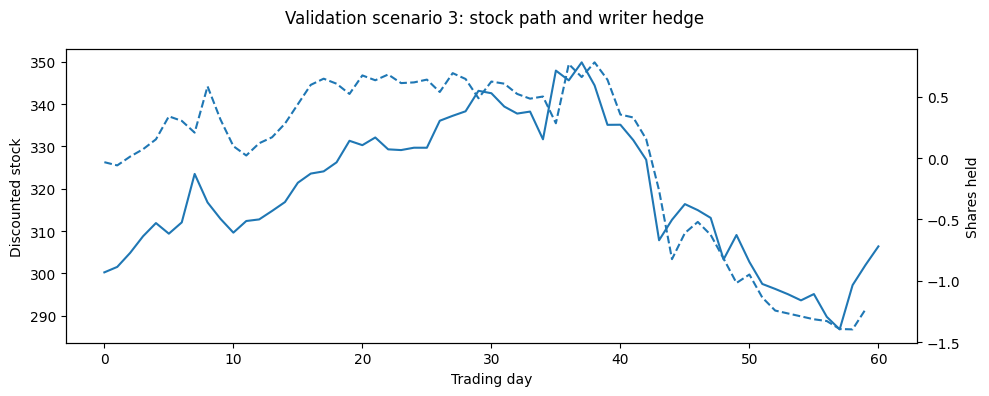

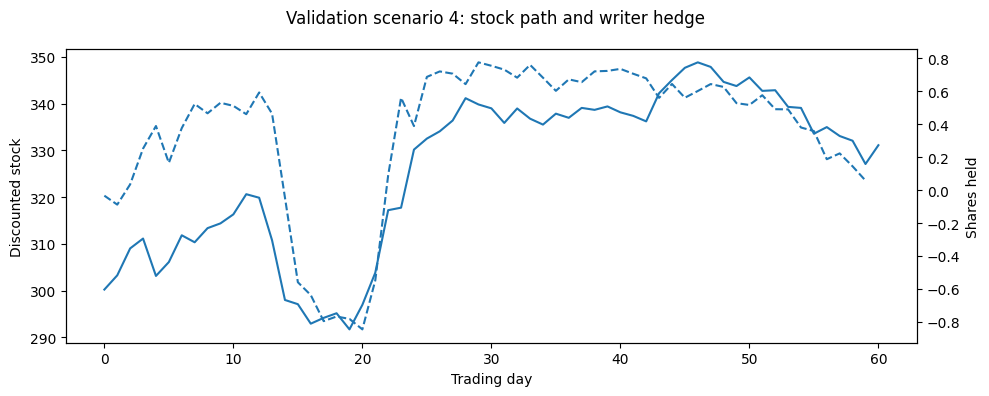

Validation scenario 0
  Discounted payoff: 67.0949
  Writer terminal wealth from hedge: 66.8288
  Writer terminal P&L after paying claim: -0.2661
  Writer downside loss: 0.2661

Validation scenario 1
  Discounted payoff: 0.0000
  Writer terminal wealth from hedge: 31.6227
  Writer terminal P&L after paying claim: 31.6227
  Writer downside loss: 0.0000

Validation scenario 2
  Discounted payoff: 10.6931
  Writer terminal wealth from hedge: 6.7036
  Writer terminal P&L after paying claim: -3.9895
  Writer downside loss: 3.9895

Validation scenario 3
  Discounted payoff: 50.8163
  Writer terminal wealth from hedge: 43.2951
  Writer terminal P&L after paying claim: -7.5212
  Writer downside loss: 7.5212

Validation scenario 4
  Discounted payoff: 50.1614
  Writer terminal wealth from hedge: 31.9746
  Writer terminal P&L after paying claim: -18.1869
  Writer downside loss: 18.1869



In [ ]:
Y_FAIR = fair_estimate["fair_price"]

writer_fair = train_best_strategy(
    train_data=train_data,
    val_data=val_data,
    x=Y_FAIR,
    epsilon=-1,
    a_max=A_MAX,
    config=optim_config,
)

buyer_fair = train_best_strategy(
    train_data=train_data,
    val_data=val_data,
    x=-Y_FAIR,
    epsilon=+1,
    a_max=A_MAX,
    config=optim_config,
)

summary = pd.DataFrame([
    {"side": "writer", "Y": Y_FAIR, **writer_fair["validation"]},
    {"side": "buyer", "Y": Y_FAIR, **buyer_fair["validation"]},
])
print(summary)


def reconstruct_bank_account(
    model: nn.Module,
    data: Dict[str, np.ndarray],
    x: float,
) -> Dict[str, np.ndarray]:
    """
    Reconstruct discounted bank-account holdings from self-financing.

    b_0 = x - a_0 * S_0
    b_k = a_{k-1} * S_k + b_{k-1} - a_k * S_k
    W_k = a_k * S_k + b_k
    """
    model.eval()
    tdata = to_torch_data(data)
    with torch.no_grad():
        a = model(tdata["features"]).detach().cpu().numpy()

    S = data["S_disc"]
    M, N_plus_1 = S.shape
    N = N_plus_1 - 1
    b = np.zeros((M, N), dtype=np.float32)
    W = np.zeros((M, N), dtype=np.float32)

    b[:, 0] = float(x) - a[:, 0] * S[:, 0]
    W[:, 0] = a[:, 0] * S[:, 0] + b[:, 0]

    for k in range(1, N):
        b[:, k] = a[:, k - 1] * S[:, k] + b[:, k - 1] - a[:, k] * S[:, k]
        W[:, k] = a[:, k] * S[:, k] + b[:, k]

    terminal_wealth = a[:, -1] * S[:, -1] + b[:, -1]
    compact_wealth = float(x) + np.sum(a * (S[:, 1:] - S[:, :-1]), axis=1)
    max_error = np.max(np.abs(terminal_wealth - compact_wealth))

    return {"a": a, "b": b, "W": W, "terminal_wealth": terminal_wealth, "max_error": max_error}


writer_recon = reconstruct_bank_account(writer_fair["model"], val_data, x=Y_FAIR)
print("Max reconstruction error:", writer_recon["max_error"])

# Plot a few validation paths and the corresponding writer stock positions.
n_plot = min(5, len(val_data["S_disc"]))
for i in range(n_plot):
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(val_data["S_disc"][i], label="Discounted stock path")
    ax1.set_xlabel("Trading day")
    ax1.set_ylabel("Discounted stock")
    ax2 = ax1.twinx()
    ax2.plot(np.arange(T_DAYS), writer_recon["a"][i], linestyle="--", label="Writer stock position a_k")
    ax2.set_ylabel("Shares held")
    fig.suptitle(f"Validation scenario {i}: stock path and writer hedge")
    fig.tight_layout()
    plt.show()
# Compute writer terminal P&L per validation scenario at the estimated fair price.
writer_terminal_wealth = writer_recon["terminal_wealth"]
writer_payoff = val_data["payoff_disc"]
writer_pnl = writer_terminal_wealth - writer_payoff

for i in range(n_plot):
    print(f"Validation scenario {i}")
    print(f"  Discounted payoff: {writer_payoff[i]:.4f}")
    print(f"  Writer terminal wealth from hedge: {writer_terminal_wealth[i]:.4f}")
    print(f"  Writer terminal P&L after paying claim: {writer_pnl[i]:.4f}")
    print(f"  Writer downside loss: {max(-writer_pnl[i], 0.0):.4f}")
    print()

American-option cell device: cpu
Ticker for Yahoo Finance data, e.g. AAPL, MSFT, SPY: AAPL
Yahoo Finance history period, e.g. 5y, 10y, max: 10y
Maturity / horizon in trading days, e.g. 63: 60
Number of sigmoidal functions m, e.g. 4: 2
Total number Q of bought American option contracts, e.g. 6: 4
{'ticker': 'AAPL', 'period': '10y', 'T_days': 60, 'sigmoids_m': 2, 'total_bought_American_options_Q': 4, 'alpha': 0.95}
Latest Yahoo close S0 for AAPL: 300.2300
Historical annualised volatility estimate: 28.8371%
American-option scenario paths: (900, 61)
{'contract_type': 'lookback_call', 'strike': 300.2300109863281, 'initial_premium_Y_default_mean_payoff': 41.321285247802734, 'a_max': 2.0, 'bank_lower_bound': -82.64257049560547}
count    900.000000
mean      41.321285
std       30.874683
min        0.000000
50%       35.945358
90%       77.644342
95%       97.697514
99%      144.332566
max      176.014984
dtype: float64
Bought American option universe:


,option_id,type,strike,initial_quantity,price
0,1,call,255.195509,1.0,49.016886
1,2,put,285.218510,1.0,9.364373
2,3,call,315.241512,1.0,11.610526
3,4,put,345.264513,1.0,47.499943


Total initial cost of bought American options C0: 117.4917
Train paths: (720, 61) Validation paths: (180, 61)
epoch    1/300 | train mean=+0.7214, train CVaR=47.6324 | val mean=+0.7924, val CVaR=40.7947
epoch   50/300 | train mean=-0.5254, train CVaR=39.5857 | val mean=-0.1801, val CVaR=33.5079
epoch  100/300 | train mean=+1.1311, train CVaR=33.8993 | val mean=+1.3115, val CVaR=30.1015
epoch  150/300 | train mean=+2.5355, train CVaR=24.1591 | val mean=+2.7427, val CVaR=22.2003
epoch  200/300 | train mean=+3.8983, train CVaR=15.4374 | val mean=+4.1578, val CVaR=13.8760
epoch  250/300 | train mean=+5.4410, train CVaR=11.8449 | val mean=+5.6336, val CVaR=11.2864
epoch  300/300 | train mean=+6.6732, train CVaR=9.4218 | val mean=+6.7788, val CVaR=9.4206

Training metrics:
mean_pnl                    6.673221
std_pnl                     9.148087
prob_loss                   0.202778
var_loss                    5.920186
cvar_loss                   9.421789
avg_abs_stock_position      0.544316


,exercise_date_index_k,avg_options_exercised_at_tk,p90_options_exercised_at_tk,avg_options_remaining_after_tk
0,1,0.063796,0.064479,3.936204
1,2,0.061932,0.062433,3.874272
2,3,0.061082,0.060966,3.813190
3,4,0.059739,0.082070,3.753451
4,5,0.059467,0.081616,3.693984
5,6,0.056438,0.078298,3.637546
6,7,0.056975,0.083485,3.580571
7,8,0.054733,0.079648,3.525837
8,9,0.053255,0.076463,3.472582
9,10,0.052950,0.075398,3.419632


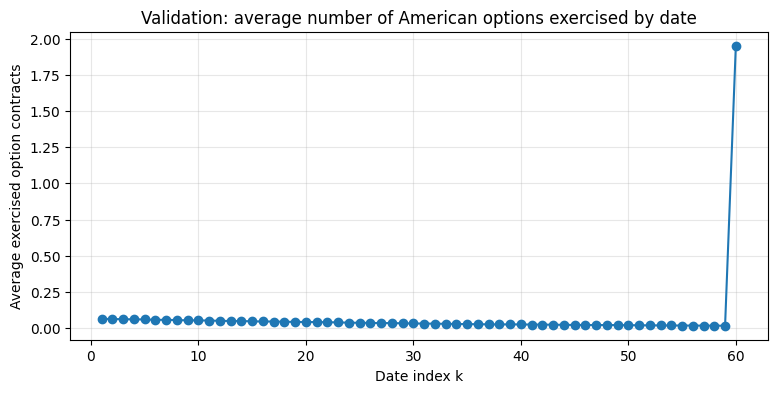

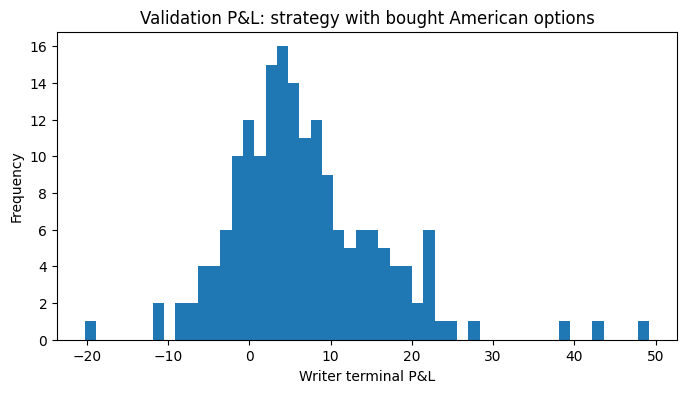


Interpretation:
- avg_options_exercised_at_tk is the empirical mean of sum_i e_{i,k} over validation paths.
- The final row k=T_DAYS is the automatic maturity exercise/liquidation of all remaining American options.
- All previous notebook cells were left untouched; this is an appended optional extension cell.


In [ ]:
# ================================================================
# NEW OPTIONAL CELL -- purchased American options + sigmoidal exercise policy
# ================================================================
# This cell is intentionally appended to the notebook.  It does not modify any
# previous variable, function, class, output, or cell.  You may run it after the
# existing cells, or run it as a largely self-contained extension.
#
# Mathematical idea
# -----------------
# We now let the hedging portfolio contain:
#
#     1. the underlying stock S,
#     2. the bank account b,
#     3. Q bought American options on the same underlying.
#
# The Q American options are bought at t_0.  Their outstanding inventories are
# denoted by
#
#     q_i^0 = 1,                 i = 1,...,Q,
#     q_i^k >= 0,                k = 0,...,N,
#
# so the total initial number of bought option contracts is
#
#     sum_{i=1}^Q q_i^0 = Q.
#
# For option i with strike K_i and type tau_i in {call, put}, define its intrinsic
# exercise value at a spot level s by
#
#     h_i(s) = (s - K_i)^+       for an American call,
#     h_i(s) = (K_i - s)^+       for an American put.
#
# At each rebalancing date t_k, the strategy decides the fraction rho_{i,k} of the
# still outstanding option q_i^k to exercise:
#
#     rho_{i,k} = sigmoid(G_theta(t_k, S_{t_k}, K_i, tau_i, path features)) in [0,1],
#     e_{i,k}   = q_i^k rho_{i,k},
#     q_i^{k+1}= q_i^k - e_{i,k}.
#
# In the code below, OTM exercise is blocked by multiplying e_{i,k} by
# 1_{h_i(S_{t_k})>0}, because exercising an out-of-the-money American option is
# never useful in this frictionless toy setting.
#
# The stock hedge is another finite sigmoidal expansion:
#
#     a_k = A_max tanh(c_0 + sum_{j=1}^m c_j sigma(w_j^T X_k + beta_j)),
#
# where the user selects m, the number of sigmoidal basis functions.
#
# If the writer receives initial premium Y and pays C_0 for the Q bought American
# options, then the self-financing terminal P&L is computed as
#
#     Pi_theta = Y - C_0
#                + sum_{k=0}^{N-1} a_k (S_{t_{k+1}} - S_{t_k})
#                + sum_{k=1}^{N-1} sum_{i=1}^Q e_{i,k} h_i(S_{t_k})
#                + sum_{i=1}^Q q_i^N h_i(S_T)
#                - f(S_{t_1},...,S_{t_N}).
#
# The last option term means that all remaining in-the-money American options are
# exercised at maturity.  The optimisation criterion is the mean-CVaR objective
#
#     maximise   E[Pi_theta] - lambda CVaR_alpha((-Pi_theta)^+),
#
# estimated empirically from Yahoo-Finance historical-return scenarios.
# ================================================================

import math
import subprocess
import sys
import warnings
from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])
    import yfinance as yf

try:
    import torch
    from torch import nn
    import torch.nn.functional as F
except ImportError as exc:
    raise ImportError("This cell requires PyTorch. In Colab, run the earlier import cell first.") from exc

AM_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("American-option cell device:", AM_DEVICE)


# ------------------------------------------------
# 1. User inputs requested in the prompt
# ------------------------------------------------
AM_USE_INTERACTIVE_INPUTS = True

if AM_USE_INTERACTIVE_INPUTS:
    AM_TICKER = input("Ticker for Yahoo Finance data, e.g. AAPL, MSFT, SPY: ").strip().upper() or globals().get("TICKER", "AAPL")
    AM_PERIOD = input("Yahoo Finance history period, e.g. 5y, 10y, max: ").strip() or "10y"
    AM_T_DAYS = int(input("Maturity / horizon in trading days, e.g. 63: ").strip() or str(globals().get("T_DAYS", 63)))
    AM_N_SIGMOIDS = int(input("Number of sigmoidal functions m, e.g. 4: ").strip() or str(globals().get("N_SIGMOIDAL_FUNCTIONS", 4)))
    AM_N_OPTIONS_TOTAL = int(input("Total number Q of bought American option contracts, e.g. 6: ").strip() or "6")
else:
    AM_TICKER = globals().get("TICKER", "AAPL")
    AM_PERIOD = "10y"
    AM_T_DAYS = int(globals().get("T_DAYS", 63))
    AM_N_SIGMOIDS = int(globals().get("N_SIGMOIDAL_FUNCTIONS", 4))
    AM_N_OPTIONS_TOTAL = 6

AM_T_DAYS = max(2, int(AM_T_DAYS))
AM_N_SIGMOIDS = max(1, int(AM_N_SIGMOIDS))
AM_N_OPTIONS_TOTAL = max(1, int(AM_N_OPTIONS_TOTAL))

# Training controls.  Increase these for a more stable, but slower, optimisation.
AM_N_SCENARIOS = 900
AM_TRAIN_FRACTION = 0.80
AM_EPOCHS = 300
AM_LR = 2e-3
AM_ALPHA = float(globals().get("ALPHA", 0.95))
AM_LAMBDA_CVAR = 1.0
AM_A_MAX_MULTIPLIER = float(globals().get("A_MAX_MULTIPLIER", 2.0))
AM_POSITION_PENALTY = 1e-5
AM_BANK_PENALTY = 1e-4
AM_SEED = int(globals().get("SEED", 42))
AM_R_ANNUAL = float(globals().get("R_ANNUAL", 0.03))
AM_TRADING_DAYS_PER_YEAR = 252

print({
    "ticker": AM_TICKER,
    "period": AM_PERIOD,
    "T_days": AM_T_DAYS,
    "sigmoids_m": AM_N_SIGMOIDS,
    "total_bought_American_options_Q": AM_N_OPTIONS_TOTAL,
    "alpha": AM_ALPHA,
})


# ------------------------------------------------
# 2. Yahoo Finance data and historical-return scenarios
# ------------------------------------------------
def am_extract_close_column(raw: pd.DataFrame) -> pd.Series:
    """Extract one adjusted-close/close series from yfinance output."""
    if raw.empty:
        raise ValueError("Yahoo Finance returned an empty DataFrame. Check the ticker/period.")

    if isinstance(raw.columns, pd.MultiIndex):
        for label in ["Close", "Adj Close"]:
            for level in range(raw.columns.nlevels):
                if label in list(raw.columns.get_level_values(level)):
                    out = raw.xs(label, axis=1, level=level)
                    if isinstance(out, pd.DataFrame):
                        out = out.iloc[:, 0]
                    return out.dropna().astype(float)
        raise ValueError("Could not find Close or Adj Close in yfinance MultiIndex columns.")

    for label in ["Close", "Adj Close"]:
        if label in raw.columns:
            return raw[label].dropna().astype(float)
    raise ValueError("Could not find Close or Adj Close in yfinance columns.")


def am_download_yahoo_close(ticker: str, period: str) -> pd.Series:
    """Download daily stock data from Yahoo Finance through yfinance."""
    raw = yf.download(
        tickers=ticker,
        period=period,
        interval="1d",
        auto_adjust=True,
        progress=False,
        threads=True,
    )
    close = am_extract_close_column(raw)
    if len(close) < AM_T_DAYS + 30:
        warnings.warn("Downloaded history is short relative to the horizon; scenarios may be unstable.")
    return close


def am_make_return_block_scenarios(
    close: pd.Series,
    horizon_days: int,
    n_scenarios: int,
    seed: int,
) -> np.ndarray:
    """
    Create paths by bootstrapping rolling blocks of historical log returns.

    All paths start at the latest Yahoo close S_0.  If r_{j+1},...,r_{j+N} is a sampled
    historical block, the scenario is

        S_{t_k} = S_0 exp(r_{j+1}+...+r_{j+k}),  k=1,...,N.
    """
    rng = np.random.default_rng(seed)
    close = close.dropna().astype(float)
    s0 = float(close.iloc[-1])
    log_returns = np.log(close / close.shift(1)).dropna().to_numpy(dtype=float)

    if len(log_returns) >= horizon_days:
        windows = np.lib.stride_tricks.sliding_window_view(log_returns, window_shape=horizon_days)
        replace = len(windows) < n_scenarios
        idx = rng.choice(len(windows), size=n_scenarios, replace=replace)
        sampled = windows[idx]
    else:
        warnings.warn("Not enough return history for rolling blocks; using iid bootstrap returns.")
        sampled = rng.choice(log_returns, size=(n_scenarios, horizon_days), replace=True)

    future = s0 * np.exp(np.cumsum(sampled, axis=1))
    paths = np.concatenate([np.full((n_scenarios, 1), s0), future], axis=1)
    return paths.astype(np.float32)


am_close = am_download_yahoo_close(AM_TICKER, AM_PERIOD)
AM_S0 = float(am_close.iloc[-1])
am_paths = am_make_return_block_scenarios(am_close, AM_T_DAYS, AM_N_SCENARIOS, AM_SEED)
am_log_returns = np.log(am_close / am_close.shift(1)).dropna().to_numpy(dtype=float)
am_hist_vol = max(float(np.std(am_log_returns, ddof=1) * math.sqrt(AM_TRADING_DAYS_PER_YEAR)), 1e-4)

print(f"Latest Yahoo close S0 for {AM_TICKER}: {AM_S0:.4f}")
print(f"Historical annualised volatility estimate: {am_hist_vol:.4%}")
print("American-option scenario paths:", am_paths.shape)


# ------------------------------------------------
# 3. Target path-dependent payoff f(S_{t_1},...,S_{t_N})
# ------------------------------------------------
def am_path_payoff(paths: np.ndarray, contract_type: str, strike: float, barrier: float = np.nan, multiplier: float = 1.0) -> np.ndarray:
    """Local payoff function, matching the contract types used earlier in the notebook."""
    paths = np.asarray(paths, dtype=np.float32)
    S_full = paths
    S_future = paths[:, 1:]
    S_T = paths[:, -1]
    K = float(strike)
    ctype = str(contract_type).lower()

    if ctype == "european_call":
        payoff = np.maximum(S_T - K, 0.0)
    elif ctype == "european_put":
        payoff = np.maximum(K - S_T, 0.0)
    elif ctype == "asian_call":
        payoff = np.maximum(S_future.mean(axis=1) - K, 0.0)
    elif ctype == "asian_put":
        payoff = np.maximum(K - S_future.mean(axis=1), 0.0)
    elif ctype == "lookback_call":
        payoff = np.maximum(S_full.max(axis=1) - K, 0.0)
    elif ctype == "lookback_put":
        payoff = np.maximum(K - S_full.min(axis=1), 0.0)
    elif ctype == "up_and_out_call":
        knocked = S_full.max(axis=1) >= float(barrier)
        payoff = np.where(knocked, 0.0, np.maximum(S_T - K, 0.0))
    elif ctype == "down_and_out_put":
        knocked = S_full.min(axis=1) <= float(barrier)
        payoff = np.where(knocked, 0.0, np.maximum(K - S_T, 0.0))
    else:
        raise ValueError(f"Unsupported AM_CONTRACT_TYPE={contract_type!r}")
    return (float(multiplier) * payoff).astype(np.float32)


AM_CONTRACT_TYPE = str(globals().get("CONTRACT_TYPE", "lookback_call"))
AM_STRIKE = float(globals().get("STRIKE", AM_S0) if globals().get("STRIKE", None) is not None else AM_S0)
if not np.isfinite(AM_STRIKE):
    AM_STRIKE = AM_S0
AM_BARRIER = float(globals().get("BARRIER", np.nan))
AM_CONTRACT_MULTIPLIER = float(globals().get("CONTRACT_MULTIPLIER", 1.0))
AM_A_MAX = AM_A_MAX_MULTIPLIER * AM_CONTRACT_MULTIPLIER

am_payoff = am_path_payoff(
    am_paths,
    contract_type=AM_CONTRACT_TYPE,
    strike=AM_STRIKE,
    barrier=AM_BARRIER,
    multiplier=AM_CONTRACT_MULTIPLIER,
)

# Default writer premium for this cell.  This is not a fair-price search; it is the
# premium at which we train one writer hedge with bought American options.
AM_INITIAL_PREMIUM = float(np.mean(am_payoff))
AM_BANK_LOWER_BOUND_M = max(1.0, 2.0 * AM_INITIAL_PREMIUM)

print({
    "contract_type": AM_CONTRACT_TYPE,
    "strike": AM_STRIKE,
    "initial_premium_Y_default_mean_payoff": AM_INITIAL_PREMIUM,
    "a_max": AM_A_MAX,
    "bank_lower_bound": -AM_BANK_LOWER_BOUND_M,
})
print(pd.Series(am_payoff).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))


# ------------------------------------------------
# 4. American option universe and approximate initial costs
# ------------------------------------------------
def am_binomial_american_price(
    s0: float,
    strike: float,
    maturity_days: int,
    r_annual: float,
    sigma_annual: float,
    option_type: str,
    steps: int = 100,
) -> float:
    """
    Cox-Ross-Rubinstein American option price used as an internal cost estimate.

    This keeps the cell self-contained.  If you have market option quotes, replace the
    returned values in am_options["price"] by the observed ask/mid prices.
    """
    T = max(float(maturity_days) / AM_TRADING_DAYS_PER_YEAR, 1.0 / AM_TRADING_DAYS_PER_YEAR)
    steps = int(max(5, min(steps, 300)))
    dt = T / steps
    sigma = max(float(sigma_annual), 1e-4)
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    disc = math.exp(-float(r_annual) * dt)
    growth = math.exp(float(r_annual) * dt)
    p = (growth - d) / (u - d)
    p = min(max(p, 1e-6), 1.0 - 1e-6)

    j = np.arange(steps + 1)
    stock_T = float(s0) * (u ** j) * (d ** (steps - j))
    if option_type == "call":
        values = np.maximum(stock_T - float(strike), 0.0)
    else:
        values = np.maximum(float(strike) - stock_T, 0.0)

    for n in range(steps - 1, -1, -1):
        stock_n = float(s0) * (u ** np.arange(n + 1)) * (d ** (n - np.arange(n + 1)))
        continuation = disc * (p * values[1:n + 2] + (1.0 - p) * values[0:n + 1])
        if option_type == "call":
            exercise = np.maximum(stock_n - float(strike), 0.0)
        else:
            exercise = np.maximum(float(strike) - stock_n, 0.0)
        values = np.maximum(continuation, exercise)
    return float(values[0])


def am_make_option_universe(
    s0: float,
    total_options: int,
    maturity_days: int,
    r_annual: float,
    sigma_annual: float,
) -> pd.DataFrame:
    """
    Construct exactly Q bought American option contracts.

    Each row represents one initially bought contract.  Calls and puts alternate and
    strikes are spread around the current spot.  Replace this construction by a real
    option-chain filter if you want to use quoted contracts only.
    """
    Q = int(total_options)
    if Q == 1:
        rel_strikes = np.array([1.0])
    else:
        rel_strikes = np.linspace(0.85, 1.15, Q)

    rows = []
    for i, rel in enumerate(rel_strikes, start=1):
        opt_type = "call" if (i % 2 == 1) else "put"
        K_i = float(s0 * rel)
        price_i = am_binomial_american_price(
            s0=s0,
            strike=K_i,
            maturity_days=maturity_days,
            r_annual=r_annual,
            sigma_annual=sigma_annual,
            option_type=opt_type,
            steps=max(50, min(150, maturity_days)),
        )
        rows.append({
            "option_id": i,
            "type": opt_type,
            "strike": K_i,
            "initial_quantity": 1.0,
            "price": price_i,
        })
    return pd.DataFrame(rows)


am_options = am_make_option_universe(
    s0=AM_S0,
    total_options=AM_N_OPTIONS_TOTAL,
    maturity_days=AM_T_DAYS,
    r_annual=AM_R_ANNUAL,
    sigma_annual=am_hist_vol,
)
AM_OPTION_INITIAL_COST = float((am_options["initial_quantity"] * am_options["price"]).sum())

print("Bought American option universe:")
try:
    display(am_options)
except NameError:
    print(am_options)
print(f"Total initial cost of bought American options C0: {AM_OPTION_INITIAL_COST:.4f}")


# ------------------------------------------------
# 5. Non-anticipative features for stock trading and option exercise
# ------------------------------------------------
def am_build_stock_features(paths: np.ndarray) -> np.ndarray:
    """Features X_k used to choose the stock position a_k before interval [t_k,t_{k+1}]."""
    S = np.asarray(paths, dtype=np.float32)
    M, N_plus_1 = S.shape
    N = N_plus_1 - 1
    s0 = S[:, [0]]
    spot = S[:, :-1]
    running_max = np.maximum.accumulate(S, axis=1)[:, :-1]
    running_min = np.minimum.accumulate(S, axis=1)[:, :-1]
    time = np.tile(np.arange(N, dtype=np.float32)[None, :] / max(N, 1), (M, 1))

    features = np.stack([
        spot / s0 - 1.0,
        np.log(np.maximum(spot, 1e-8) / np.maximum(s0, 1e-8)),
        running_max / s0 - 1.0,
        running_min / s0 - 1.0,
        time,
    ], axis=-1)
    return features.astype(np.float32)


def am_build_option_features(paths: np.ndarray, options: pd.DataFrame) -> np.ndarray:
    """
    Features used to choose early exercise fractions rho_{i,k} at t_k, k=1,...,N-1.

    The feature tensor has shape (M, N-1, Q, d).  The decision at t_k uses S_{t_k},
    so it is non-anticipative.  The terminal date T is handled separately by automatic
    exercise of all remaining in-the-money options.
    """
    S = np.asarray(paths, dtype=np.float32)
    M, N_plus_1 = S.shape
    N = N_plus_1 - 1
    Q = len(options)
    if N <= 1:
        return np.zeros((M, 0, Q, 6), dtype=np.float32)

    s0 = S[:, [0]]
    spot = S[:, 1:-1]  # early exercise dates t_1,...,t_{N-1}
    n_early = spot.shape[1]
    time = np.tile((np.arange(1, N, dtype=np.float32) / max(N, 1))[None, :, None], (M, 1, Q))

    strikes = options["strike"].to_numpy(dtype=np.float32)[None, None, :]
    is_call = (options["type"].to_numpy() == "call").astype(np.float32)[None, None, :]
    is_put = 1.0 - is_call

    spot3 = spot[:, :, None]
    s03 = s0[:, None, :]
    log_moneyness = np.log(np.maximum(spot3, 1e-8) / np.maximum(strikes, 1e-8))
    rel_spot = spot3 / np.maximum(s03, 1e-8) - 1.0
    call_intr = np.maximum(spot3 - strikes, 0.0) / np.maximum(s03, 1e-8)
    put_intr = np.maximum(strikes - spot3, 0.0) / np.maximum(s03, 1e-8)
    rel_intrinsic = is_call * call_intr + is_put * put_intr

    features = np.stack([
        time,
        np.broadcast_to(rel_spot, (M, n_early, Q)),
        log_moneyness,
        rel_intrinsic,
        np.broadcast_to(is_call, (M, n_early, Q)),
        np.broadcast_to(is_put, (M, n_early, Q)),
    ], axis=-1)
    return features.astype(np.float32)


def am_train_val_split(paths: np.ndarray, payoff: np.ndarray, options: pd.DataFrame, train_fraction: float, seed: int) -> Tuple[Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    rng = np.random.default_rng(seed)
    M = paths.shape[0]
    idx = rng.permutation(M)
    n_train = int(train_fraction * M)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:]

    stock_features = am_build_stock_features(paths)
    option_features = am_build_option_features(paths, options)

    def pack(idxs: np.ndarray) -> Dict[str, np.ndarray]:
        return {
            "paths": paths[idxs].astype(np.float32),
            "payoff": payoff[idxs].astype(np.float32),
            "stock_features": stock_features[idxs].astype(np.float32),
            "option_features": option_features[idxs].astype(np.float32),
        }

    return pack(train_idx), pack(val_idx)


am_train_data, am_val_data = am_train_val_split(am_paths, am_payoff, am_options, AM_TRAIN_FRACTION, AM_SEED)
print("Train paths:", am_train_data["paths"].shape, "Validation paths:", am_val_data["paths"].shape)


# ------------------------------------------------
# 6. Sigmoidal networks for a_k and rho_{i,k}
# ------------------------------------------------
class AMFiniteSigmoidNet(nn.Module):
    """
    One-hidden-layer finite sigmoidal expansion.

    For input x, this represents

        y(x) = output_activation(B_0 + sum_{j=1}^m B_j sigma(A_j x + beta_j)).

    The parameter m is exactly the user-selected AM_N_SIGMOIDS.
    """
    def __init__(self, input_dim: int, n_sigmoids: int, output_dim: int = 1, activation: str = "tanh"):
        super().__init__()
        self.input_to_basis = nn.Linear(input_dim, n_sigmoids)
        self.basis_to_output = nn.Linear(n_sigmoids, output_dim)
        self.activation = activation

    def basis(self, z: torch.Tensor) -> torch.Tensor:
        if self.activation == "logistic":
            return torch.sigmoid(z)
        return torch.tanh(z)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.basis_to_output(self.basis(self.input_to_basis(x)))


class AmericanOptionExerciseHedge(nn.Module):
    """Joint stock-position and American-option exercise policy."""
    def __init__(self, stock_dim: int, option_dim: int, n_sigmoids: int, a_max: float):
        super().__init__()
        self.stock_net = AMFiniteSigmoidNet(stock_dim, n_sigmoids, output_dim=1, activation="tanh")
        self.exercise_net = AMFiniteSigmoidNet(option_dim, n_sigmoids, output_dim=1, activation="tanh")
        self.a_max = float(a_max)

    def stock_positions(self, stock_features: torch.Tensor) -> torch.Tensor:
        # a_k in [-A_max, A_max]. Shape: (M, N).
        raw = self.stock_net(stock_features).squeeze(-1)
        return self.a_max * torch.tanh(raw)

    def exercise_fractions(self, option_features: torch.Tensor) -> torch.Tensor:
        # rho_{i,k} in [0,1]. Shape: (M, N-1, Q).
        if option_features.shape[1] == 0:
            return torch.zeros(option_features.shape[:-1], dtype=option_features.dtype, device=option_features.device)
        raw = self.exercise_net(option_features).squeeze(-1)
        return torch.sigmoid(raw)


def am_to_torch(data: Dict[str, np.ndarray]) -> Dict[str, torch.Tensor]:
    return {k: torch.as_tensor(v, dtype=torch.float32, device=AM_DEVICE) for k, v in data.items()}


def am_option_intrinsic_tensor(S_vec: torch.Tensor, strikes: torch.Tensor, is_call: torch.Tensor) -> torch.Tensor:
    """Return h_i(S) for all scenarios and all options. Shape: (M, Q)."""
    S_mat = S_vec[:, None]
    call_payoff = torch.relu(S_mat - strikes[None, :])
    put_payoff = torch.relu(strikes[None, :] - S_mat)
    return is_call[None, :] * call_payoff + (1.0 - is_call[None, :]) * put_payoff


def am_cvar_ru(losses: torch.Tensor, eta: torch.Tensor, alpha: float) -> torch.Tensor:
    """Rockafellar-Uryasev empirical CVaR_alpha(losses)."""
    return eta + torch.mean(torch.relu(losses - eta)) / (1.0 - float(alpha))


def am_simulate_strategy(
    model: AmericanOptionExerciseHedge,
    data_t: Dict[str, torch.Tensor],
    options: pd.DataFrame,
    initial_premium: float,
) -> Dict[str, torch.Tensor]:
    """
    Simulate the self-financing writer P&L with bought American options.

    The compact P&L formula implemented here is exactly the mathematical expression
    written at the top of the cell.
    """
    S = data_t["paths"]
    payoff = data_t["payoff"]
    stock_features = data_t["stock_features"]
    option_features = data_t["option_features"]
    M = S.shape[0]
    N = S.shape[1] - 1
    Q = len(options)

    strikes = torch.as_tensor(options["strike"].to_numpy(dtype=np.float32), device=AM_DEVICE)
    is_call = torch.as_tensor((options["type"].to_numpy() == "call").astype(np.float32), device=AM_DEVICE)
    initial_q = torch.as_tensor(options["initial_quantity"].to_numpy(dtype=np.float32), device=AM_DEVICE)
    initial_cost = torch.as_tensor(float((options["initial_quantity"] * options["price"]).sum()), dtype=torch.float32, device=AM_DEVICE)

    a = model.stock_positions(stock_features)
    dS = S[:, 1:] - S[:, :-1]
    stock_gains = torch.sum(a * dS, dim=1)

    rho = model.exercise_fractions(option_features)
    remaining = initial_q[None, :].repeat(M, 1)
    early_cash = torch.zeros(M, dtype=torch.float32, device=AM_DEVICE)
    early_exercised_by_time = []
    remaining_by_time = []

    # Early exercise at t_1,...,t_{N-1}.  At T all remaining ITM options are exercised.
    for k in range(max(N - 1, 0)):
        S_k = S[:, k + 1]
        intrinsic_k = am_option_intrinsic_tensor(S_k, strikes, is_call)
        itm_mask = (intrinsic_k > 0.0).float()
        exercised_k = remaining * rho[:, k, :] * itm_mask
        early_cash = early_cash + torch.sum(exercised_k * intrinsic_k, dim=1)
        remaining = remaining - exercised_k
        early_exercised_by_time.append(torch.sum(exercised_k, dim=1))
        remaining_by_time.append(torch.sum(remaining, dim=1))

    terminal_intrinsic = am_option_intrinsic_tensor(S[:, -1], strikes, is_call)
    terminal_cash = torch.sum(remaining * terminal_intrinsic, dim=1)

    # Compact terminal writer P&L.
    pnl = float(initial_premium) - initial_cost + stock_gains + early_cash + terminal_cash - payoff

    # Bank-account path for a soft lower-bound penalty:
    # b_0 = Y - C_0 - a_0 S_0,
    # b_{k+1} = b_k + option_exercise_cash_{k+1} - (a_{k+1}-a_k)S_{k+1}.
    bank = float(initial_premium) - initial_cost - a[:, 0] * S[:, 0]
    min_bank = bank.clone()
    remaining_bank = initial_q[None, :].repeat(M, 1)
    for k in range(max(N - 1, 0)):
        S_k = S[:, k + 1]
        intrinsic_k = am_option_intrinsic_tensor(S_k, strikes, is_call)
        itm_mask = (intrinsic_k > 0.0).float()
        exercised_k = remaining_bank * rho[:, k, :] * itm_mask
        cash_k = torch.sum(exercised_k * intrinsic_k, dim=1)
        remaining_bank = remaining_bank - exercised_k
        bank = bank + cash_k - (a[:, k + 1] - a[:, k]) * S_k
        min_bank = torch.minimum(min_bank, bank)

    if early_exercised_by_time:
        exercise_time_matrix = torch.stack(early_exercised_by_time, dim=1)
        remaining_time_matrix = torch.stack(remaining_by_time, dim=1)
    else:
        exercise_time_matrix = torch.zeros((M, 0), dtype=torch.float32, device=AM_DEVICE)
        remaining_time_matrix = torch.zeros((M, 0), dtype=torch.float32, device=AM_DEVICE)

    return {
        "pnl": pnl,
        "stock_positions": a,
        "rho": rho,
        "exercise_by_time": exercise_time_matrix,
        "remaining_by_time": remaining_time_matrix,
        "terminal_remaining": remaining,
        "min_bank": min_bank,
        "initial_option_cost": initial_cost,
    }


# ------------------------------------------------
# 7. Training and diagnostics
# ------------------------------------------------
def am_empirical_cvar_np(losses: np.ndarray, alpha: float) -> float:
    losses = np.asarray(losses, dtype=float)
    q = float(np.quantile(losses, alpha))
    return float(q + np.mean(np.maximum(losses - q, 0.0)) / (1.0 - alpha))


def am_evaluate(model: AmericanOptionExerciseHedge, data: Dict[str, np.ndarray], options: pd.DataFrame, initial_premium: float, alpha: float) -> Tuple[Dict[str, float], Dict[str, np.ndarray]]:
    model.eval()
    data_t = am_to_torch(data)
    with torch.no_grad():
        out = am_simulate_strategy(model, data_t, options, initial_premium)
    pnl = out["pnl"].detach().cpu().numpy()
    losses = np.maximum(-pnl, 0.0)
    exercise_by_time = out["exercise_by_time"].detach().cpu().numpy()
    remaining_by_time = out["remaining_by_time"].detach().cpu().numpy()
    terminal_remaining = out["terminal_remaining"].detach().cpu().numpy()
    a = out["stock_positions"].detach().cpu().numpy()
    min_bank = out["min_bank"].detach().cpu().numpy()

    metrics = {
        "mean_pnl": float(np.mean(pnl)),
        "std_pnl": float(np.std(pnl)),
        "prob_loss": float(np.mean(pnl < 0.0)),
        "var_loss": float(np.quantile(losses, alpha)),
        "cvar_loss": am_empirical_cvar_np(losses, alpha),
        "avg_abs_stock_position": float(np.mean(np.abs(a))),
        "avg_min_bank": float(np.mean(min_bank)),
        "worst_min_bank": float(np.min(min_bank)),
    }
    arrays = {
        "pnl": pnl,
        "losses": losses,
        "exercise_by_time": exercise_by_time,
        "remaining_by_time": remaining_by_time,
        "terminal_remaining": terminal_remaining,
        "stock_positions": a,
        "min_bank": min_bank,
    }
    return metrics, arrays


def am_train_strategy(train_data: Dict[str, np.ndarray], val_data: Dict[str, np.ndarray], options: pd.DataFrame) -> AmericanOptionExerciseHedge:
    torch.manual_seed(AM_SEED)
    np.random.seed(AM_SEED)

    stock_dim = train_data["stock_features"].shape[-1]
    option_dim = train_data["option_features"].shape[-1]
    model = AmericanOptionExerciseHedge(stock_dim, option_dim, AM_N_SIGMOIDS, AM_A_MAX).to(AM_DEVICE)
    eta = nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=AM_DEVICE))
    optimizer = torch.optim.Adam(list(model.parameters()) + [eta], lr=AM_LR)
    train_t = am_to_torch(train_data)

    for epoch in range(1, AM_EPOCHS + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        out = am_simulate_strategy(model, train_t, options, AM_INITIAL_PREMIUM)
        pnl = out["pnl"]
        downside_loss = torch.relu(-pnl)
        cvar = am_cvar_ru(downside_loss, eta, AM_ALPHA)
        mean_pnl = torch.mean(pnl)
        position_penalty = AM_POSITION_PENALTY * torch.mean(out["stock_positions"] ** 2)
        bank_penalty = AM_BANK_PENALTY * torch.mean(torch.relu(-AM_BANK_LOWER_BOUND_M - out["min_bank"]) ** 2)

        # We minimise the negative of the mean-CVaR criterion plus soft penalties.
        objective = mean_pnl - AM_LAMBDA_CVAR * cvar - position_penalty - bank_penalty
        loss = -objective
        loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % max(25, AM_EPOCHS // 6) == 0 or epoch == AM_EPOCHS:
            with torch.no_grad():
                train_metrics, _ = am_evaluate(model, train_data, options, AM_INITIAL_PREMIUM, AM_ALPHA)
                val_metrics, _ = am_evaluate(model, val_data, options, AM_INITIAL_PREMIUM, AM_ALPHA)
            print(
                f"epoch {epoch:4d}/{AM_EPOCHS} | "
                f"train mean={train_metrics['mean_pnl']:+.4f}, train CVaR={train_metrics['cvar_loss']:.4f} | "
                f"val mean={val_metrics['mean_pnl']:+.4f}, val CVaR={val_metrics['cvar_loss']:.4f}"
            )
    return model


am_model = am_train_strategy(am_train_data, am_val_data, am_options)
am_train_metrics, am_train_arrays = am_evaluate(am_model, am_train_data, am_options, AM_INITIAL_PREMIUM, AM_ALPHA)
am_val_metrics, am_val_arrays = am_evaluate(am_model, am_val_data, am_options, AM_INITIAL_PREMIUM, AM_ALPHA)

print("\nTraining metrics:")
print(pd.Series(am_train_metrics))
print("\nValidation metrics:")
print(pd.Series(am_val_metrics))


# ------------------------------------------------
# 8. How many American options are exercised at each time?
# ------------------------------------------------
def am_make_exercise_summary(arrays: Dict[str, np.ndarray], horizon_days: int) -> pd.DataFrame:
    ex = arrays["exercise_by_time"]
    rem = arrays["remaining_by_time"]
    rows = []
    for j in range(ex.shape[1]):
        rows.append({
            "exercise_date_index_k": j + 1,
            "avg_options_exercised_at_tk": float(np.mean(ex[:, j])),
            "p90_options_exercised_at_tk": float(np.quantile(ex[:, j], 0.90)),
            "avg_options_remaining_after_tk": float(np.mean(rem[:, j])),
        })
    # Maturity: all remaining ITM options are liquidated/exercised if valuable.
    rows.append({
        "exercise_date_index_k": horizon_days,
        "avg_options_exercised_at_tk": float(np.mean(np.sum(arrays["terminal_remaining"], axis=1))),
        "p90_options_exercised_at_tk": float(np.quantile(np.sum(arrays["terminal_remaining"], axis=1), 0.90)),
        "avg_options_remaining_after_tk": 0.0,
    })
    return pd.DataFrame(rows)


am_exercise_summary = am_make_exercise_summary(am_val_arrays, AM_T_DAYS)
print("\nAverage number of American options exercised by date on validation scenarios:")
try:
    display(am_exercise_summary)
except NameError:
    print(am_exercise_summary)

plt.figure(figsize=(9, 4))
plt.plot(am_exercise_summary["exercise_date_index_k"], am_exercise_summary["avg_options_exercised_at_tk"], marker="o")
plt.title("Validation: average number of American options exercised by date")
plt.xlabel("Date index k")
plt.ylabel("Average exercised option contracts")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(am_val_arrays["pnl"], bins=50)
plt.title("Validation P&L: strategy with bought American options")
plt.xlabel("Writer terminal P&L")
plt.ylabel("Frequency")
plt.show()

print("\nInterpretation:")
print("- avg_options_exercised_at_tk is the empirical mean of sum_i e_{i,k} over validation paths.")
print("- The final row k=T_DAYS is the automatic maturity exercise/liquidation of all remaining American options.")
print("- All previous notebook cells were left untouched; this is an appended optional extension cell.")


Comparison device: cpu
{'same_initial_premium_Y': 41.321285247802734, 'same_sigmoidal_basis_count_m': 2, 'same_CVaR_alpha': 0.95, 'same_lambda': 1.0, 'comparison_train_paths': (720, 61), 'comparison_validation_paths': (180, 61)}
stock-only epoch    1/300 | train mean=-19.9145, train CVaR=183.5966 | val mean=-13.0885, val CVaR=149.2128
stock-only epoch   50/300 | train mean=-10.5441, train CVaR=136.6288 | val mean=-5.3136, val CVaR=111.2772
stock-only epoch  100/300 | train mean=+0.5452, train CVaR=80.3831 | val mean=+3.8771, val CVaR=68.1503
stock-only epoch  150/300 | train mean=+10.8078, train CVaR=41.7145 | val mean=+12.4217, val CVaR=39.2297
stock-only epoch  200/300 | train mean=+13.8841, train CVaR=38.3124 | val mean=+14.9748, val CVaR=36.3535
stock-only epoch  250/300 | train mean=+14.5454, train CVaR=37.1069 | val mean=+15.5126, val CVaR=35.1870
stock-only epoch  300/300 | train mean=+14.8539, train CVaR=36.0206 | val mean=+15.7566, val CVaR=34.0779

Side-by-side strategy compa

,split,strategy,mean_pnl,std_pnl,prob_loss,var_loss,cvar_loss,mean_minus_lambda_cvar,avg_abs_stock_position,avg_min_bank,worst_min_bank,p05_pnl,median_pnl,p95_pnl,initial_option_cost
0,train,asset + bank account,14.853873,17.922436,0.143056,22.513212,36.020647,-21.166771,0.663257,-218.765228,-300.391663,-22.513214,16.914062,38.128670,0.000000
1,train,asset + bank account + bought American options,6.673221,9.148087,0.202778,5.920186,9.421789,-2.748568,0.544316,-362.432678,-403.462799,-5.920186,5.361446,24.262915,117.491728
2,validation,asset + bank account,15.756563,16.795448,0.127778,16.527872,34.077909,-18.321344,0.657609,-215.921219,-298.282043,-16.527863,18.647661,38.480682,0.000000
3,validation,asset + bank account + bought American options,6.778849,9.257331,0.216667,5.327700,9.420615,-2.641767,0.552902,-362.498657,-413.848572,-5.327700,5.365829,22.263485,117.491728



Incremental effect of adding bought American options:


,split,comparison,mean_pnl,std_pnl,prob_loss,var_loss,cvar_loss,mean_minus_lambda_cvar,avg_abs_stock_position,avg_min_bank,worst_min_bank,p05_pnl,median_pnl,p95_pnl,initial_option_cost
0,train,American-options strategy minus stock-only str...,-8.180652,-8.774349,0.059722,-16.593027,-26.598858,18.418203,-0.118941,-143.667450,-103.071136,16.593028,-11.552616,-13.865755,117.491728
1,validation,American-options strategy minus stock-only str...,-8.977715,-7.538117,0.088889,-11.200172,-24.657294,15.679578,-0.104708,-146.577438,-115.566528,11.200162,-13.281832,-16.217197,117.491728


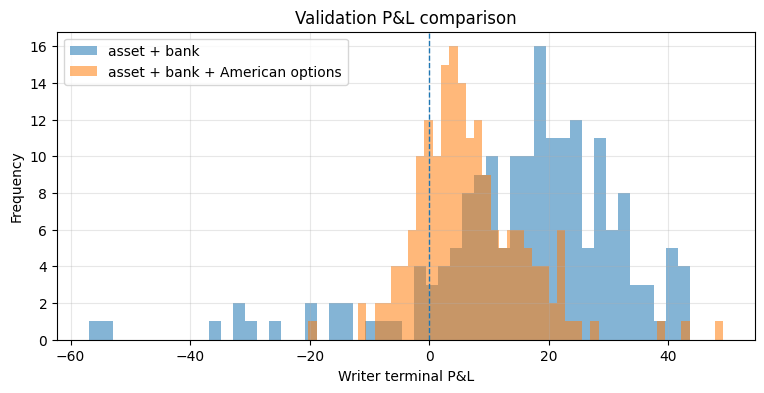

/tmp/ipykernel_8680/3846053363.py:360: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([stock_losses, amer_losses], labels=["asset+bank", "asset+bank+American"])


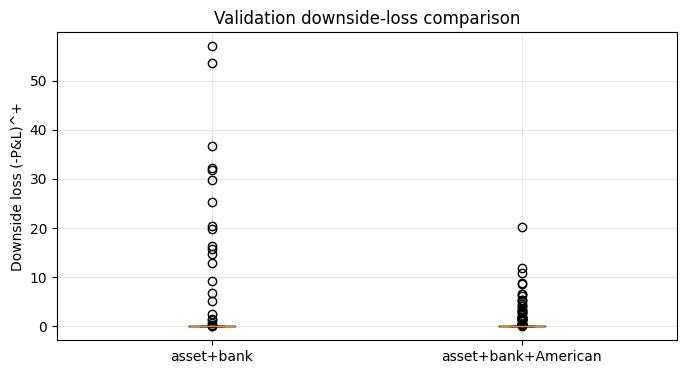

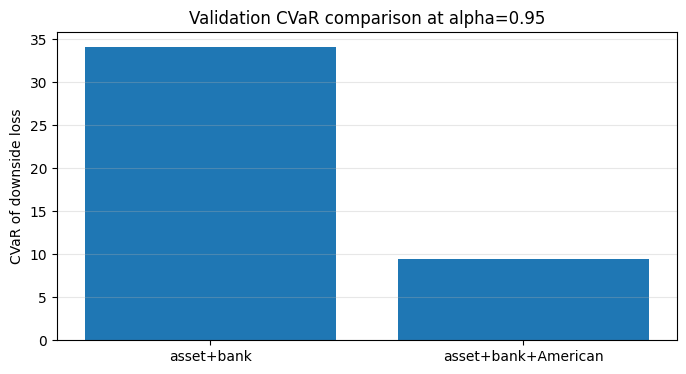


Reading the comparison:
- Higher mean_minus_lambda_cvar is better because it is the trained objective E[Pi] - lambda CVaR.
- Lower cvar_loss, var_loss, prob_loss and std_pnl indicate lower downside/tail risk.
- initial_option_cost is paid only by the American-options strategy, so the comparison is net of that upfront cost.
- All paths, payoff parameters, premium Y, alpha, lambda and stock-policy sigmoid count m are held fixed across the two strategies.


In [ ]:
# ================================================================
# NEW OPTIONAL CELL -- comparison: stock+bank vs stock+bank+American options
# ================================================================
# This cell is appended after the American-option extension cell.  It does not
# edit or overwrite any previous notebook cell.  It constructs a fair benchmark:
#
#   Strategy A: underlying asset + bank account only.
#   Strategy B: underlying asset + bank account + bought American options.
#
# Both strategies are evaluated on the same Yahoo-Finance historical-return
# scenarios, with the same path-dependent payoff f, the same initial premium Y,
# the same number m of sigmoidal basis functions for the stock hedge, and the
# same mean-CVaR objective.
#
# Mathematical comparison
# -----------------------
# Let S_k := S_{t_k}.  In the stock-only benchmark, the strategy chooses a
# predictable stock position a_k before the interval [t_k,t_{k+1}], and its
# self-financing terminal P&L is
#
#     Pi_stock(theta)
#       = Y + sum_{k=0}^{N-1} a_k^theta (S_{k+1}-S_k)
#           - f(S_1,...,S_N).
#
# Equivalently, with b_0 = Y - a_0 S_0 and
#
#     b_{k+1} = b_k - (a_{k+1}-a_k) S_{k+1},
#
# the terminal wealth equals a_{N-1} S_N + b_{N-1}, which is exactly
# Y + sum_k a_k Delta S_{k+1}.  This is the asset+bank-account strategy.
#
# In the American-option strategy already trained in the previous appended cell,
# the P&L is
#
#     Pi_Amer(theta)
#       = Y - C_0
#         + sum_{k=0}^{N-1} a_k^theta (S_{k+1}-S_k)
#         + sum_{k=1}^{N-1} sum_i e_{i,k}^theta h_i(S_k)
#         + sum_i q_i^N h_i(S_N)
#         - f(S_1,...,S_N),
#
# where C_0 is the initial cost of the bought American options,
# e_{i,k}=q_i^k rho_{i,k} is the exercised quantity at t_k, and q_i^N is the
# remaining inventory exercised/liquidated at maturity when valuable.
#
# For both strategies we maximise the empirical mean-CVaR criterion
#
#     J(theta) = E[Pi(theta)] - lambda CVaR_alpha( ( -Pi(theta) )^+ ).
#
# The final tables report both raw P&L statistics and the incremental value of
# adding the bought American options:
#
#     Delta metric = metric(asset+bank+American options) - metric(asset+bank).
# ================================================================

from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    from torch import nn
except ImportError as exc:
    raise ImportError("This comparison cell requires PyTorch. Run the earlier import cells first.") from exc

# ------------------------------------------------
# 0. Preconditions: the previous appended American-option cell must have run
# ------------------------------------------------
_required_names_for_comparison = [
    "AM_DEVICE", "AM_SEED", "AM_ALPHA", "AM_LAMBDA_CVAR", "AM_LR", "AM_EPOCHS",
    "AM_A_MAX", "AM_BANK_LOWER_BOUND_M", "AM_POSITION_PENALTY", "AM_BANK_PENALTY",
    "AM_INITIAL_PREMIUM", "AM_N_SIGMOIDS", "am_train_data", "am_val_data",
    "am_options", "am_to_torch", "am_cvar_ru", "am_empirical_cvar_np",
    "am_evaluate", "am_train_strategy", "am_simulate_strategy", "AmericanOptionExerciseHedge",
]
_missing_names = [name for name in _required_names_for_comparison if name not in globals()]
if _missing_names:
    raise RuntimeError(
        "Run the previous appended American-option cell first. Missing names: "
        + ", ".join(_missing_names)
    )

print("Comparison device:", AM_DEVICE)
print({
    "same_initial_premium_Y": AM_INITIAL_PREMIUM,
    "same_sigmoidal_basis_count_m": AM_N_SIGMOIDS,
    "same_CVaR_alpha": AM_ALPHA,
    "same_lambda": AM_LAMBDA_CVAR,
    "comparison_train_paths": am_train_data["paths"].shape,
    "comparison_validation_paths": am_val_data["paths"].shape,
})


# ------------------------------------------------
# 1. Stock+bank-only model with the same sigmoidal stock policy class
# ------------------------------------------------
class AMStockBankOnlyHedge(nn.Module):
    """
    Neural sigmoidal feedback rule for the stock-only benchmark.

    Input:  X_k = non-anticipative stock/path features at t_k.
    Output: a_k in [-AM_A_MAX, AM_A_MAX].

    We use AMFiniteSigmoidNet if it exists from the previous cell; otherwise we
    define the same one-hidden-layer finite sigmoid expansion locally.
    """
    def __init__(self, stock_dim: int, n_sigmoids: int, a_max: float):
        super().__init__()
        if "AMFiniteSigmoidNet" in globals():
            self.stock_net = AMFiniteSigmoidNet(stock_dim, n_sigmoids, output_dim=1, activation="tanh")
        else:
            self.stock_net = nn.Sequential(
                nn.Linear(stock_dim, n_sigmoids),
                nn.Tanh(),
                nn.Linear(n_sigmoids, 1),
            )
        self.a_max = float(a_max)

    def stock_positions(self, stock_features: torch.Tensor) -> torch.Tensor:
        raw = self.stock_net(stock_features).squeeze(-1)
        return self.a_max * torch.tanh(raw)

    def forward(self, stock_features: torch.Tensor) -> torch.Tensor:
        return self.stock_positions(stock_features)


def am_simulate_stock_bank_only_strategy(
    model: AMStockBankOnlyHedge,
    data_t: Dict[str, torch.Tensor],
    initial_premium: float,
) -> Dict[str, torch.Tensor]:
    """
    Simulate the asset+bank-account strategy.

    The model chooses a_k before the move S_k -> S_{k+1}.  Therefore the
    cumulative stock-trading gain is

        sum_{k=0}^{N-1} a_k (S_{k+1}-S_k).

    The bank path is tracked only for diagnostics and for the soft lower-bound
    penalty used during training.
    """
    S = data_t["paths"]
    payoff = data_t["payoff"]
    stock_features = data_t["stock_features"]

    a = model.stock_positions(stock_features)
    dS = S[:, 1:] - S[:, :-1]
    stock_gains = torch.sum(a * dS, dim=1)
    pnl = float(initial_premium) + stock_gains - payoff

    # Bank recursion consistent with self-financing stock trading.
    bank = float(initial_premium) - a[:, 0] * S[:, 0]
    min_bank = bank.clone()
    N = S.shape[1] - 1
    for k in range(max(N - 1, 0)):
        bank = bank - (a[:, k + 1] - a[:, k]) * S[:, k + 1]
        min_bank = torch.minimum(min_bank, bank)

    return {
        "pnl": pnl,
        "stock_positions": a,
        "min_bank": min_bank,
    }


def am_evaluate_stock_bank_only(
    model: AMStockBankOnlyHedge,
    data: Dict[str, np.ndarray],
    initial_premium: float,
    alpha: float,
) -> Tuple[Dict[str, float], Dict[str, np.ndarray]]:
    """Evaluate asset+bank-only P&L and risk diagnostics."""
    model.eval()
    data_t = am_to_torch(data)
    with torch.no_grad():
        out = am_simulate_stock_bank_only_strategy(model, data_t, initial_premium)

    pnl = out["pnl"].detach().cpu().numpy()
    losses = np.maximum(-pnl, 0.0)
    a = out["stock_positions"].detach().cpu().numpy()
    min_bank = out["min_bank"].detach().cpu().numpy()

    metrics = {
        "mean_pnl": float(np.mean(pnl)),
        "std_pnl": float(np.std(pnl)),
        "prob_loss": float(np.mean(pnl < 0.0)),
        "var_loss": float(np.quantile(losses, alpha)),
        "cvar_loss": am_empirical_cvar_np(losses, alpha),
        "mean_minus_lambda_cvar": float(np.mean(pnl) - AM_LAMBDA_CVAR * am_empirical_cvar_np(losses, alpha)),
        "avg_abs_stock_position": float(np.mean(np.abs(a))),
        "avg_min_bank": float(np.mean(min_bank)),
        "worst_min_bank": float(np.min(min_bank)),
        "p05_pnl": float(np.quantile(pnl, 0.05)),
        "median_pnl": float(np.quantile(pnl, 0.50)),
        "p95_pnl": float(np.quantile(pnl, 0.95)),
    }
    arrays = {
        "pnl": pnl,
        "losses": losses,
        "stock_positions": a,
        "min_bank": min_bank,
    }
    return metrics, arrays


def am_train_stock_bank_only_strategy(
    train_data: Dict[str, np.ndarray],
    val_data: Dict[str, np.ndarray],
) -> AMStockBankOnlyHedge:
    """Train the asset+bank-only benchmark under the same mean-CVaR criterion."""
    torch.manual_seed(AM_SEED + 17)
    np.random.seed(AM_SEED + 17)

    stock_dim = train_data["stock_features"].shape[-1]
    model = AMStockBankOnlyHedge(stock_dim, AM_N_SIGMOIDS, AM_A_MAX).to(AM_DEVICE)
    eta = nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=AM_DEVICE))
    optimizer = torch.optim.Adam(list(model.parameters()) + [eta], lr=AM_LR)
    train_t = am_to_torch(train_data)

    for epoch in range(1, AM_EPOCHS + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        out = am_simulate_stock_bank_only_strategy(model, train_t, AM_INITIAL_PREMIUM)
        pnl = out["pnl"]
        downside_loss = torch.relu(-pnl)
        cvar = am_cvar_ru(downside_loss, eta, AM_ALPHA)
        mean_pnl = torch.mean(pnl)
        position_penalty = AM_POSITION_PENALTY * torch.mean(out["stock_positions"] ** 2)
        bank_penalty = AM_BANK_PENALTY * torch.mean(torch.relu(-AM_BANK_LOWER_BOUND_M - out["min_bank"]) ** 2)

        objective = mean_pnl - AM_LAMBDA_CVAR * cvar - position_penalty - bank_penalty
        loss = -objective
        loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % max(25, AM_EPOCHS // 6) == 0 or epoch == AM_EPOCHS:
            with torch.no_grad():
                tr_m, _ = am_evaluate_stock_bank_only(model, train_data, AM_INITIAL_PREMIUM, AM_ALPHA)
                va_m, _ = am_evaluate_stock_bank_only(model, val_data, AM_INITIAL_PREMIUM, AM_ALPHA)
            print(
                f"stock-only epoch {epoch:4d}/{AM_EPOCHS} | "
                f"train mean={tr_m['mean_pnl']:+.4f}, train CVaR={tr_m['cvar_loss']:.4f} | "
                f"val mean={va_m['mean_pnl']:+.4f}, val CVaR={va_m['cvar_loss']:.4f}"
            )
    return model


# ------------------------------------------------
# 2. Ensure the American-option strategy exists, then train the stock-only benchmark
# ------------------------------------------------
if "am_model" not in globals() or not isinstance(am_model, AmericanOptionExerciseHedge):
    print("No trained American-option model found; training it now using the previous cell's function.")
    am_model = am_train_strategy(am_train_data, am_val_data, am_options)

am_stock_only_model = am_train_stock_bank_only_strategy(am_train_data, am_val_data)


# ------------------------------------------------
# 3. Evaluate both strategies on the same train/validation sets
# ------------------------------------------------
am_stock_train_metrics, am_stock_train_arrays = am_evaluate_stock_bank_only(
    am_stock_only_model, am_train_data, AM_INITIAL_PREMIUM, AM_ALPHA
)
am_stock_val_metrics, am_stock_val_arrays = am_evaluate_stock_bank_only(
    am_stock_only_model, am_val_data, AM_INITIAL_PREMIUM, AM_ALPHA
)

am_amer_train_metrics, am_amer_train_arrays = am_evaluate(
    am_model, am_train_data, am_options, AM_INITIAL_PREMIUM, AM_ALPHA
)
am_amer_val_metrics, am_amer_val_arrays = am_evaluate(
    am_model, am_val_data, am_options, AM_INITIAL_PREMIUM, AM_ALPHA
)

# Add comparable objective and quantiles to the American-option metrics.
def am_enrich_metrics(metrics: Dict[str, float], arrays: Dict[str, np.ndarray]) -> Dict[str, float]:
    enriched = dict(metrics)
    pnl = arrays["pnl"]
    losses = np.maximum(-pnl, 0.0)
    enriched["mean_minus_lambda_cvar"] = float(np.mean(pnl) - AM_LAMBDA_CVAR * am_empirical_cvar_np(losses, AM_ALPHA))
    enriched["p05_pnl"] = float(np.quantile(pnl, 0.05))
    enriched["median_pnl"] = float(np.quantile(pnl, 0.50))
    enriched["p95_pnl"] = float(np.quantile(pnl, 0.95))
    enriched["initial_option_cost"] = float((am_options["initial_quantity"] * am_options["price"]).sum())
    return enriched

am_amer_train_metrics = am_enrich_metrics(am_amer_train_metrics, am_amer_train_arrays)
am_amer_val_metrics = am_enrich_metrics(am_amer_val_metrics, am_amer_val_arrays)

am_stock_train_metrics["initial_option_cost"] = 0.0
am_stock_val_metrics["initial_option_cost"] = 0.0

comparison_rows = []
for split_name, stock_m, amer_m in [
    ("train", am_stock_train_metrics, am_amer_train_metrics),
    ("validation", am_stock_val_metrics, am_amer_val_metrics),
]:
    row_stock = {"split": split_name, "strategy": "asset + bank account", **stock_m}
    row_amer = {"split": split_name, "strategy": "asset + bank account + bought American options", **amer_m}
    comparison_rows.extend([row_stock, row_amer])

am_strategy_comparison = pd.DataFrame(comparison_rows)

# Incremental table: positive Delta mean_minus_lambda_cvar is good; negative Delta
# cvar_loss/prob_loss/std_pnl is good because it means risk was reduced.
metric_order = [
    "mean_pnl", "std_pnl", "prob_loss", "var_loss", "cvar_loss",
    "mean_minus_lambda_cvar", "avg_abs_stock_position", "avg_min_bank",
    "worst_min_bank", "p05_pnl", "median_pnl", "p95_pnl", "initial_option_cost",
]

delta_rows = []
for split_name in ["train", "validation"]:
    stock_row = am_strategy_comparison[(am_strategy_comparison["split"] == split_name) & (am_strategy_comparison["strategy"] == "asset + bank account")].iloc[0]
    amer_row = am_strategy_comparison[(am_strategy_comparison["split"] == split_name) & (am_strategy_comparison["strategy"] == "asset + bank account + bought American options")].iloc[0]
    delta = {"split": split_name, "comparison": "American-options strategy minus stock-only strategy"}
    for metric in metric_order:
        delta[metric] = float(amer_row[metric] - stock_row[metric])
    delta_rows.append(delta)

am_strategy_delta = pd.DataFrame(delta_rows)

print("\nSide-by-side strategy comparison:")
try:
    display(am_strategy_comparison[["split", "strategy"] + metric_order])
except NameError:
    print(am_strategy_comparison[["split", "strategy"] + metric_order])

print("\nIncremental effect of adding bought American options:")
try:
    display(am_strategy_delta[["split", "comparison"] + metric_order])
except NameError:
    print(am_strategy_delta[["split", "comparison"] + metric_order])


# ------------------------------------------------
# 4. Validation plots: P&L distributions and tail losses
# ------------------------------------------------
stock_pnl = am_stock_val_arrays["pnl"]
amer_pnl = am_amer_val_arrays["pnl"]
stock_losses = np.maximum(-stock_pnl, 0.0)
amer_losses = np.maximum(-amer_pnl, 0.0)

plt.figure(figsize=(9, 4))
plt.hist(stock_pnl, bins=50, alpha=0.55, label="asset + bank")
plt.hist(amer_pnl, bins=50, alpha=0.55, label="asset + bank + American options")
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.title("Validation P&L comparison")
plt.xlabel("Writer terminal P&L")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot([stock_losses, amer_losses], labels=["asset+bank", "asset+bank+American"])
plt.title("Validation downside-loss comparison")
plt.ylabel("Downside loss (-P&L)^+")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
summary_for_bars = am_strategy_comparison[am_strategy_comparison["split"] == "validation"].set_index("strategy")
bar_labels = ["asset+bank", "asset+bank+American"]
bar_values = [
    summary_for_bars.loc["asset + bank account", "cvar_loss"],
    summary_for_bars.loc["asset + bank account + bought American options", "cvar_loss"],
]
plt.bar(bar_labels, bar_values)
plt.title(f"Validation CVaR comparison at alpha={AM_ALPHA}")
plt.ylabel("CVaR of downside loss")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

print("\nReading the comparison:")
print("- Higher mean_minus_lambda_cvar is better because it is the trained objective E[Pi] - lambda CVaR.")
print("- Lower cvar_loss, var_loss, prob_loss and std_pnl indicate lower downside/tail risk.")
print("- initial_option_cost is paid only by the American-options strategy, so the comparison is net of that upfront cost.")
print("- All paths, payoff parameters, premium Y, alpha, lambda and stock-policy sigmoid count m are held fixed across the two strategies.")
